# Collateralized Bilateral CVA/DVA for an Interest Rate Swap

This notebook implements a full counterparty credit risk workflow for a
collateralized interest rate swap. The pipeline includes Hull-White interest
rate simulation, swap exposure generation, collateralized exposure, credit
hazard curves, bilateral first-to-default CVA/DVA, stress testing, wrong-way
risk, and EVT tail exposure analysis.

## Initial curve loading

In [ ]:
# ------------------------------------------------------------

# Notebook setup

# ------------------------------------------------------------

# This notebook runs the full workflow:
#   1. load the ECB zero curve
#   2. calibrate Hull-White parameters
#   3. simulate rates
#   4. price an at-market IRS
#   5. compute exposure, collateralized exposure, CVA/DVA,stress scenarios, wrong-way risk, and EVT tail exposure.


# ------------------------------------------------------------

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.rates.curves import load_latest_ecb_zero_curve
from src.rates.hull_white import simulate_hull_white_euler, hull_white_theta
from src.rates.calibration import estimate_historical_hw_parameters,estimate_vasicek_ols,prepare_short_rate_data

In [ ]:
# ------------------------------------------------------------
# Load initial ECB zero curve
# ------------------------------------------------------------
# The ECB AAA zero curve is used as the initial risk-free term
# structure. The curve provides zero rates R(0,T), from which we
# compute discount factors P(0,T) and instantaneous forward rates.
#
# rates_are_percent=True converts ECB percentage rates into decimals.
# cubic interpolation gives a smooth curve for Hull-White theta(t).
# ------------------------------------------------------------

curve = load_latest_ecb_zero_curve(
    csv_path=PROJECT_ROOT / "data/raw/ecb_aaa_spot_yield_curve.csv",
    rates_are_percent=True,
    interpolation="cubic",
)

curve.maturities, curve.zero_rates
curve = load_latest_ecb_zero_curve(
    csv_path=PROJECT_ROOT / "data/raw/ecb_aaa_spot_yield_curve.csv",
    rates_are_percent=True,
    interpolation="cubic",
)

curve.maturities, curve.zero_rates

(array([ 0.25,  1.  ,  2.  ,  5.  ,  7.  , 10.  ]),
 array([0.02282303, 0.02431758, 0.02475699, 0.02584226, 0.02715398,
        0.02916041]))

## Initial curve diagnostics

The zero curve, discount curve, and instantaneous forward curve are plotted to
check that the ECB input curve behaves sensibly before it is used in the
Hull-White simulation. The Hull-White drift term \(\theta(t)\) depends on the
initial forward curve, so curve smoothness matters.

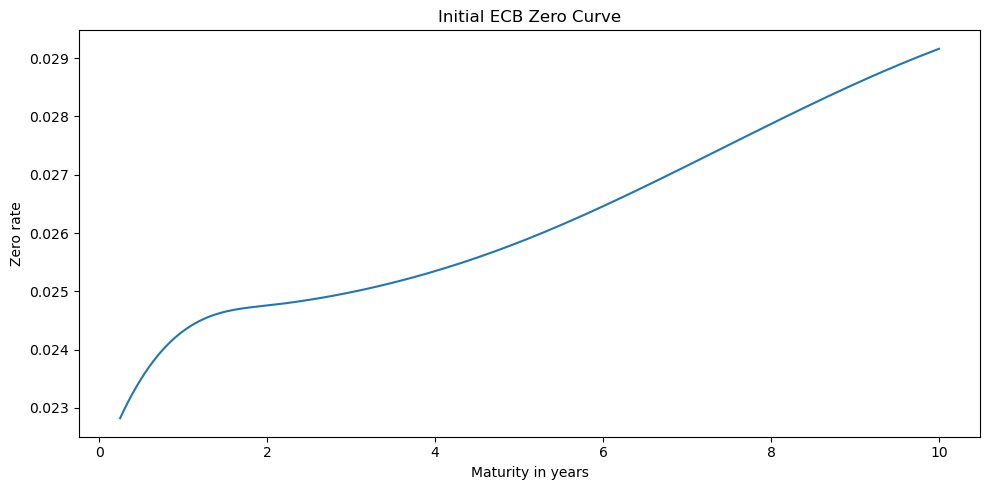

In [3]:
T_grid = np.linspace(0.25, 10.0, 200)
zero_rates = curve.zero_rate(T_grid)

plt.figure(figsize=(10, 5))
plt.plot(T_grid, zero_rates)
plt.title("Initial ECB Zero Curve")
plt.xlabel("Maturity in years")
plt.ylabel("Zero rate")
plt.tight_layout()
plt.show()

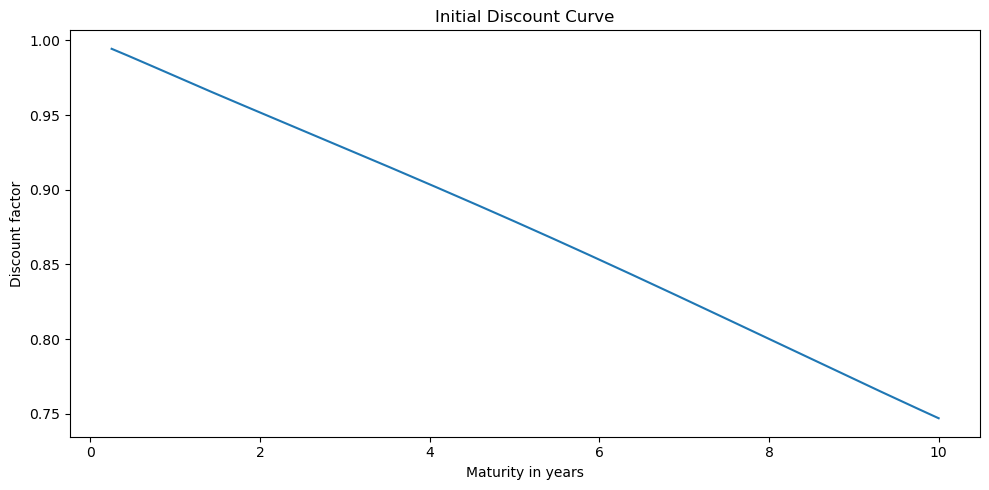

In [4]:
dfs = curve.discount_factor(T_grid)

plt.figure(figsize=(10, 5))
plt.plot(T_grid, dfs)
plt.title("Initial Discount Curve")
plt.xlabel("Maturity in years")
plt.ylabel("Discount factor")
plt.tight_layout()
plt.show()

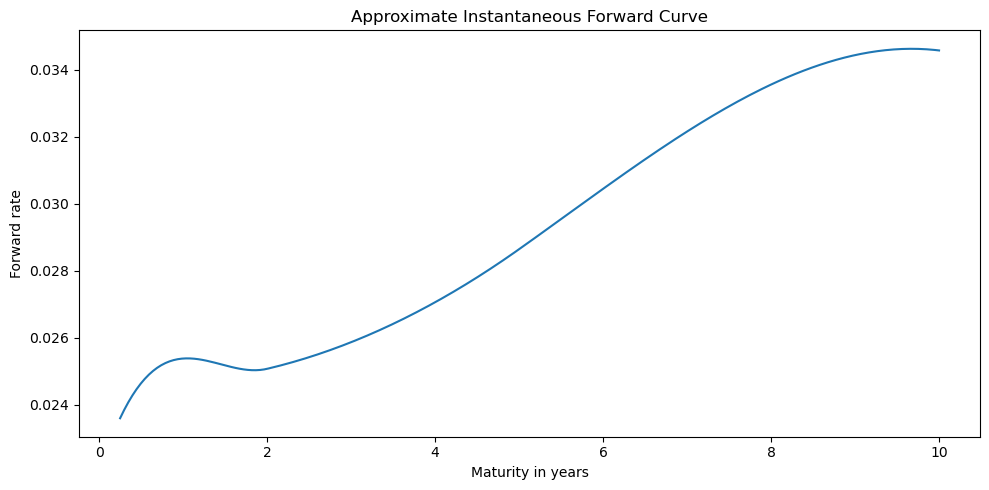

In [5]:
forwards = curve.instantaneous_forward_rate(T_grid)

plt.figure(figsize=(10, 5))
plt.plot(T_grid, forwards)
plt.title("Approximate Instantaneous Forward Curve")
plt.xlabel("Maturity in years")
plt.ylabel("Forward rate")
plt.tight_layout()
plt.show()

## Hull-White historical parameter estimation

In [ ]:
# ------------------------------------------------------------
# Load historical ECB rates for Hull-White parameter estimation
# ------------------------------------------------------------
# The historical ECB curve data is used to construct a short-rate
# proxy. We convert spot-rate columns from percentages to decimals
# before estimating mean reversion and volatility.
#
# The prepare_short_rate_data function creates the short_rate series
# used for AR(1)-style estimation of Hull-White dynamic parameters.
# ------------------------------------------------------------

df = pd.read_csv(
    PROJECT_ROOT / "data/raw/ecb_aaa_spot_yield_curve.csv",
    parse_dates=["date"],
)

rate_cols = [col for col in df.columns if col.startswith("spot_")]
df[rate_cols] = df[rate_cols] / 100.0

short_rates = prepare_short_rate_data(df)
df = pd.read_csv(

    PROJECT_ROOT / "data/raw/ecb_aaa_spot_yield_curve.csv",

    parse_dates=["date"]

)

rate_cols = [col for col in df.columns if col.startswith("spot_")]

df[rate_cols] = df[rate_cols] / 100.0

short_rates = prepare_short_rate_data(df)


In [7]:
# ------------------------------------------------------------
# Full-sample historical estimate
# ------------------------------------------------------------
# This is computed for diagnostic comparison only.
# It is not the final baseline used in the Hull-White simulation.
# The final baseline is selected later from the calibration-window table.
# ------------------------------------------------------------
hw_params = estimate_historical_hw_parameters(
    short_rates["short_rate"],
    delta_t=1 / 252,
)

a = hw_params.a
sigma = hw_params.sigma

print(f"a = {a:.6f}")
print(f"sigma = {sigma:.6f}")
print(f"Historical HW mean reversion a: {a:.6f}")
print(f"Historical HW volatility sigma: {sigma:.6f}")
print("Note: b is not used in Hull-White; theta(t) is fitted to the initial curve.")

a = 0.031719
sigma = 0.004372
Historical HW mean reversion a: 0.031719
Historical HW volatility sigma: 0.004372
Note: b is not used in Hull-White; theta(t) is fitted to the initial curve.


In [ ]:
# ------------------------------------------------------------
# Estimate Hull-White parameters across calibration windows
# ------------------------------------------------------------
# We estimate historical mean reversion and volatility using several
# windows to assess parameter instability:
#
#   - Full sample
#   - Last 10 years
#   - Last 5 years
#   - Post-2022
#
# This helps justify why the Last 5Y window is selected as the
# baseline and why the other estimates are useful for model-risk
# discussion.
# ------------------------------------------------------------

short_rates["date"] = pd.to_datetime(short_rates["date"])

windows = {
    "Full sample": short_rates,
    "Last 10Y": short_rates[
        short_rates["date"] >= short_rates["date"].max() - pd.DateOffset(years=10)
    ],
    "Last 5Y": short_rates[
        short_rates["date"] >= short_rates["date"].max() - pd.DateOffset(years=5)
    ],
    "Post 2022": short_rates[
        short_rates["date"] >= pd.Timestamp("2022-01-01")
    ],
}

rows = []

for name, data in windows.items():
    try:
        p = estimate_historical_hw_parameters(
            data["short_rate"],
            delta_t=1 / 252
        )

        rows.append({
            "window": name,
            "n_obs": len(data),
            "a": p.a,
            "sigma": p.sigma,
            "phi": p.phi,
            "half_life_years": np.log(2) / p.a,
        })

    except Exception as e:
        rows.append({
            "window": name,
            "n_obs": len(data),
            "a": np.nan,
            "sigma": np.nan,
            "phi": np.nan,
            "half_life_years": np.nan,
            "error": str(e),
        })

params_by_window = pd.DataFrame(rows)

params_by_window[["window", "n_obs", "a", "sigma", "phi", "half_life_years"]]

,window,n_obs,a,sigma,phi,half_life_years
0,Full sample,5573,0.031719,0.004372,0.999874,21.852655
1,Last 10Y,2551,0.003964,0.004009,0.999984,174.859621
2,Last 5Y,1279,0.296758,0.004991,0.998823,2.335729
3,Post 2022,1144,0.549645,0.005222,0.997821,1.261081


In [10]:
# ------------------------------------------------------------
# Select baseline Hull-White calibration window
# ------------------------------------------------------------
# We use the Last 5Y window as the baseline because it provides
# a balance between recent monetary-regime relevance and enough
# observations for estimation.
#
# The Last 10Y and Full Sample estimates imply extremely slow
# mean reversion, likely due to mixing the negative-rate regime
# with the recent hiking cycle. Post-2022 is more current but is
# dominated by a single hiking regime, so it is retained as a
# stress scenario rather than the baseline.
# ------------------------------------------------------------

baseline_window = "Last 5Y"

baseline_row = params_by_window.loc[
    params_by_window["window"] == baseline_window
].iloc[0]

hw_a = float(baseline_row["a"])
hw_sigma = float(baseline_row["sigma"])

print(f"Selected Hull-White baseline window: {baseline_window}")
print(f"HW a: {hw_a:.6f}")
print(f"HW sigma: {hw_sigma:.6f}")
print(f"Half-life: {np.log(2) / hw_a:.2f} years")

Selected Hull-White baseline window: Last 5Y
HW a: 0.296758
HW sigma: 0.004991
Half-life: 2.34 years


In [11]:
# ------------------------------------------------------------
# Save all calibration-window estimates
# ------------------------------------------------------------
# These estimates allow us to document parameter instability and
# later stress the Hull-White exposure simulation under different
# historical calibration windows.
# ------------------------------------------------------------

output_path = PROJECT_ROOT / "data/processed/hull_white_parameter_windows.csv"
params_by_window.to_csv(output_path, index=False)

params_by_window

,window,n_obs,a,sigma,phi,half_life_years
0,Full sample,5573,0.031719,0.004372,0.999874,21.852655
1,Last 10Y,2551,0.003964,0.004009,0.999984,174.859621
2,Last 5Y,1279,0.296758,0.004991,0.998823,2.335729
3,Post 2022,1144,0.549645,0.005222,0.997821,1.261081


The baseline Hull-White dynamic parameters are estimated using the last five
years of ECB short-rate proxy data. This window is selected because it reflects
the current post-negative-rate monetary environment while still providing more
than 1,000 daily observations.

The full-sample and last-10-year estimates imply extremely slow mean reversion,
which likely reflects the mixing of different monetary regimes, including the
euro-area negative-rate period and the recent hiking cycle. The post-2022 window
produces faster mean reversion but is dominated by a single hiking regime.
Therefore, the last-five-year calibration is used as the baseline, while the
other windows are retained for stress testing and model-risk analysis.

In [12]:
# ------------------------------------------------------------
# Define initial short-rate proxy
# ------------------------------------------------------------
# Hull-White simulates the short rate r_t, so we need an initial
# value r0 at time 0.
#
# The true instantaneous short rate is not directly observable from
# the ECB curve, so we use the 3M zero rate as a practical proxy:
#
#     r0 = R(0, 0.25)
#
# where 0.25 represents three months in years.
# ------------------------------------------------------------

r0 = float(curve.zero_rate(0.25))

print(f"Initial short-rate proxy r0: {r0:.6f}")

Initial short-rate proxy r0: 0.022823


## Hull-White Monte Carlo simulation

In [ ]:
# ------------------------------------------------------------

# Simulate Hull-White short-rate paths

# ------------------------------------------------------------

# The simulation uses the selected historical estimates of:

#   - mean reversion a
#   - volatility sigma
#

# The initial curve enters through theta(t), so the model is fitted to today's ECB zero curve 
# while using historical dynamics for rate uncertainty
# We simulate daily steps over five years:

#   n_steps = 252 * 5
#   n_paths = 10,000

# The simulator also stores Gaussian rate shocks, which are later reused in the wrong-way risk extension.

# ------------------------------------------------------------

hw_sim = simulate_hull_white_euler(
    r0=r0,
    curve=curve,
    a=hw_a,
    sigma=hw_sigma,
    maturity=5.0,
    n_steps=252 * 5,
    n_paths=10_000,
    seed=42,
)

In [ ]:
# ------------------------------------------------------------
# Check simulation output dimensions
# ------------------------------------------------------------
# Wrong-way risk requires one Gaussian shock per path and per
# simulation interval.
# ------------------------------------------------------------

print("Rates shape:", hw_sim.rates.shape)
print("Time grid shape:", hw_sim.time_grid.shape)
print("Shocks shape:", hw_sim.shocks.shape)

Rates shape: (10000, 1261)
Time grid shape: (1261,)
Shocks shape: (10000, 1260)


In [15]:
# ------------------------------------------------------------
# Import swap pricing tools
# ------------------------------------------------------------
# These functions define the swap contract, price it under
# Hull-White conditional zero-coupon bond prices, and compute
# exposure profiles used later for CVA and DVA.
# ------------------------------------------------------------

from src.derivatives.swap import (
    InterestRateSwap,
    price_swap_exposure_cube_hull_white,
    positive_exposure,
    negative_exposure,
    expected_exposure,
    potential_future_exposure,
    par_swap_rate_from_curve,
)

In [16]:
# ------------------------------------------------------------
# Define an at-market 5Y payer swap
# ------------------------------------------------------------
# We now compute the fixed rate as the par swap rate from the
# initial zero curve:
#
#     K_par = (1 - P(0,T_n)) / sum_i alpha_i P(0,T_i)
#
# This is better than using the 5Y zero rate as a rough proxy.
# With K = K_par, the initial swap value should be close to zero.
# ------------------------------------------------------------

notional = 10_000_000
maturity = 5.0
payment_frequency = 2

fixed_rate = par_swap_rate_from_curve(
    maturity=maturity,
    payment_frequency=payment_frequency,
    curve=curve,
)

swap = InterestRateSwap(
    notional=notional,
    fixed_rate=fixed_rate,
    maturity=maturity,
    payment_frequency=payment_frequency,
    swap_type="payer",
)

print(f"Par swap fixed rate: {fixed_rate:.6%}")
print(swap)

Par swap fixed rate: 2.596482%
InterestRateSwap(notional=10000000, fixed_rate=0.025964820325688823, maturity=5.0, payment_frequency=2, swap_type='payer')


In [17]:
# ------------------------------------------------------------
# Price the swap using Hull-White conditional bond prices
# ------------------------------------------------------------
# Important:
# We no longer use realized pathwise discount factors to price
# future swap cash flows. Instead, at each time t and path m, we
# use the simulated short rate r_m(t) inside the Hull-White
# zero-coupon bond formula P_m(t,T).
#
# This should make the initial swap value identical across paths.
# ------------------------------------------------------------

swap_values = price_swap_exposure_cube_hull_white(
    swap=swap,
    time_grid=hw_sim.time_grid,
    rates=hw_sim.rates,
    curve=curve,
    a=hw_a,
    sigma=hw_sigma,
)

swap_values.shape

(10000, 1261)

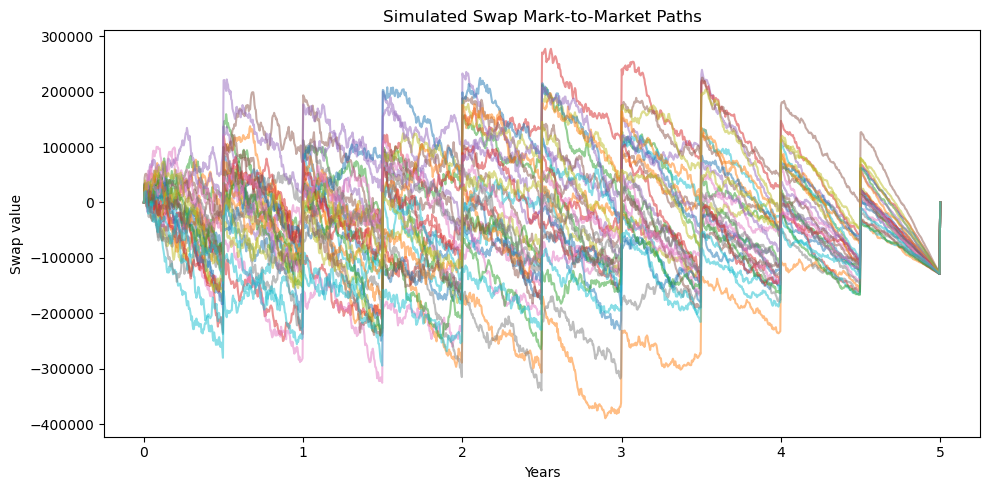

In [18]:
# ------------------------------------------------------------
# Plot sample mark-to-market paths
# ------------------------------------------------------------
# These paths show how the swap value evolves under simulated
# interest-rate scenarios.
#
# For a payer swap:
#   - value tends to increase when rates rise
#   - value tends to decrease when rates fall
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

for i in range(30):
    plt.plot(hw_sim.time_grid, swap_values[i], alpha=0.5)

plt.title("Simulated Swap Mark-to-Market Paths")
plt.xlabel("Years")
plt.ylabel("Swap value")
plt.tight_layout()
plt.show()

In [19]:
# ------------------------------------------------------------
# Compute positive and negative exposure
# ------------------------------------------------------------
# Positive exposure feeds CVA:
#   E(t) = max(V(t), 0)
#
# Negative exposure feeds DVA:
#   NE(t) = max(-V(t), 0)
# ------------------------------------------------------------

pos_exp = positive_exposure(swap_values)
neg_exp = negative_exposure(swap_values)

ee = expected_exposure(pos_exp)
ene = expected_exposure(neg_exp)

pfe_95 = potential_future_exposure(pos_exp, quantile=0.95)
pfe_99 = potential_future_exposure(pos_exp, quantile=0.99)

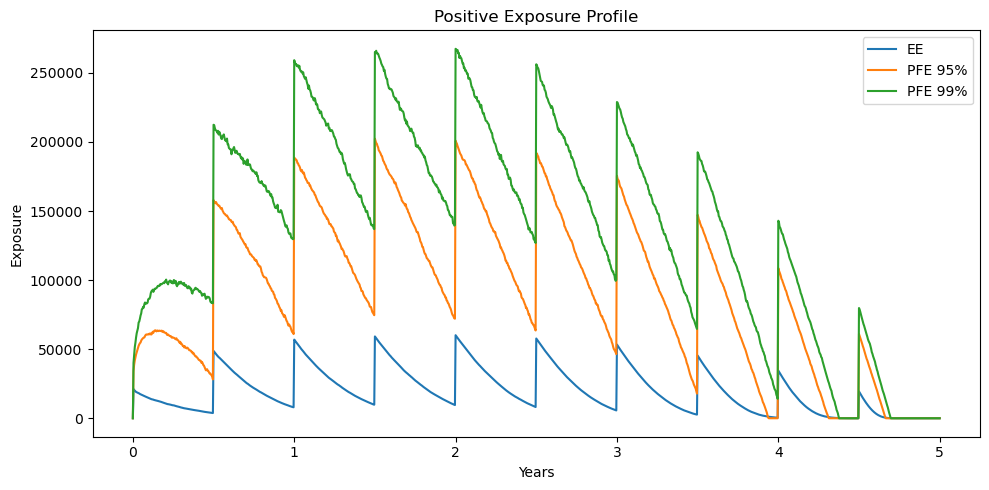

In [20]:
# ------------------------------------------------------------
# Plot exposure profiles
# ------------------------------------------------------------
# EE is the average positive exposure.
# PFE is a high quantile of exposure and captures tail exposure.
#
# These profiles are central in counterparty credit risk.
# CVA will use expected exposure. PFE is more useful for risk
# limits and stress-style exposure analysis.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(hw_sim.time_grid, ee, label="EE")
plt.plot(hw_sim.time_grid, pfe_95, label="PFE 95%")
plt.plot(hw_sim.time_grid, pfe_99, label="PFE 99%")
plt.title("Positive Exposure Profile")
plt.xlabel("Years")
plt.ylabel("Exposure")
plt.legend()
plt.tight_layout()
plt.show()

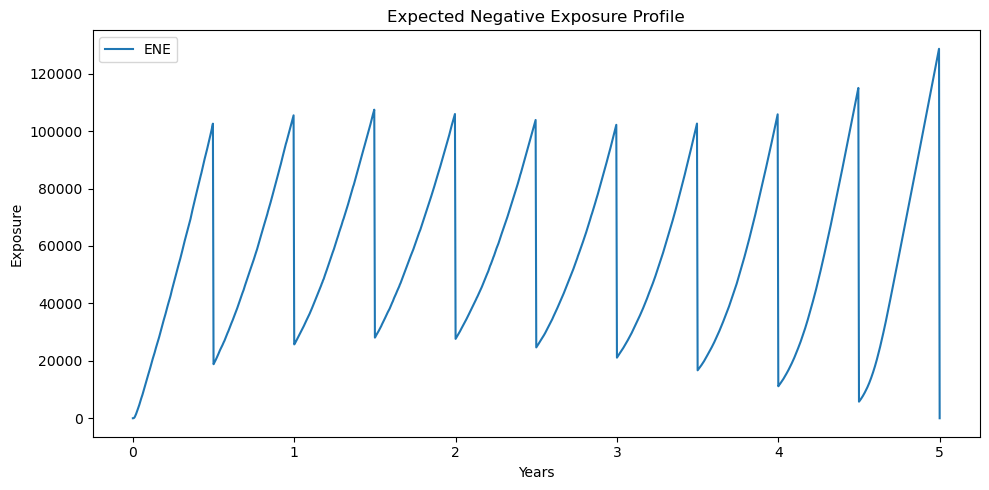

In [21]:
# ------------------------------------------------------------
# Plot expected negative exposure
# ------------------------------------------------------------
# ENE is the average amount owed by the bank to the counterparty.
# This will later feed DVA.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(hw_sim.time_grid, ene, label="ENE")
plt.title("Expected Negative Exposure Profile")
plt.xlabel("Years")
plt.ylabel("Exposure")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# ------------------------------------------------------------
# Basic numerical sanity checks
# ------------------------------------------------------------
# We check:
#   - initial swap value
#   - maximum exposure
#   - average exposure
#
# If these numbers are absurd, we fix the swap pricing before
# touching CVA. CVA built on bad exposure is just nonsense with
# discount factors.
# ------------------------------------------------------------

print(f"Initial mean swap value: {swap_values[:, 0].mean():,.2f}")
print(f"Initial min swap value:  {swap_values[:, 0].min():,.2f}")
print(f"Initial max swap value:  {swap_values[:, 0].max():,.2f}")

print(f"Max positive exposure:  {pos_exp.max():,.2f}")
print(f"Max negative exposure:  {neg_exp.max():,.2f}")

print(f"Average EE over time:   {ee.mean():,.2f}")
print(f"Average ENE over time:  {ene.mean():,.2f}")

Initial mean swap value: 0.00
Initial min swap value:  0.00
Initial max swap value:  0.00
Max positive exposure:  435,876.29
Max negative exposure:  580,806.84
Average EE over time:   19,500.05
Average ENE over time:  56,792.35


In [23]:
# ------------------------------------------------------------
# Exposure summary table
# ------------------------------------------------------------
# This compact table is useful for the notebook and later README.
# ------------------------------------------------------------

exposure_summary = pd.DataFrame([
    {
        "metric": "Initial swap value",
        "value": swap_values[:, 0].mean(),
    },
    {
        "metric": "Average EE",
        "value": ee.mean(),
    },
    {
        "metric": "Average ENE",
        "value": ene.mean(),
    },
    {
        "metric": "Maximum positive exposure",
        "value": pos_exp.max(),
    },
    {
        "metric": "Maximum negative exposure",
        "value": neg_exp.max(),
    },
    {
        "metric": "Peak PFE 95%",
        "value": pfe_95.max(),
    },
    {
        "metric": "Peak PFE 99%",
        "value": pfe_99.max(),
    },
])

exposure_summary

,metric,value
0,Initial swap value,0.000000
1,Average EE,19500.050482
2,Average ENE,56792.348111
3,Maximum positive exposure,435876.289785
4,Maximum negative exposure,580806.841633
5,Peak PFE 95%,202340.970785
6,Peak PFE 99%,267424.118188


In [24]:
# ------------------------------------------------------------
# Sanity test: off-market swap should NOT have zero initial value
# ------------------------------------------------------------
# If we increase the fixed rate above par, the payer swap should
# have a negative initial value because paying above-market fixed
# is economically unfavorable.
#
# This test checks that the model is not artificially forcing the
# initial swap value to zero.
# ------------------------------------------------------------

off_market_swap = InterestRateSwap(
    notional=notional,
    fixed_rate=fixed_rate + 0.005,  # +50 bps above par
    maturity=maturity,
    payment_frequency=payment_frequency,
    swap_type="payer",
)

off_market_values = price_swap_exposure_cube_hull_white(
    swap=off_market_swap,
    time_grid=hw_sim.time_grid,
    rates=hw_sim.rates,
    curve=curve,
    a=hw_a,
    sigma=hw_sigma,
)

print(f"Off-market initial mean value: {off_market_values[:, 0].mean():,.2f}")
print(f"Off-market initial min value:  {off_market_values[:, 0].min():,.2f}")
print(f"Off-market initial max value:  {off_market_values[:, 0].max():,.2f}")
print(f"Off-market initial std:        {off_market_values[:, 0].std():,.8f}")

Off-market initial mean value: -233,415.35
Off-market initial min value:  -233,415.35
Off-market initial max value:  -233,415.35
Off-market initial std:        0.00000000


## Swap pricing and exposure generation

The Hull-White model generates simulated short-rate paths. At each future
simulation date, the swap is repriced using the Hull-White conditional
zero-coupon bond formula \(P(t,T)\), based on the simulated short rate
\(r_t\), the initial ECB zero curve, and the calibrated Hull-White parameters.

This is important because realized pathwise discount factors from \(0\) to \(T\)
are not the same as conditional bond prices at time \(t\). Using conditional
bond prices ensures that the initial swap value is identical across all Monte
Carlo paths.

In [25]:
# ------------------------------------------------------------
# Import collateral and margining tools
# ------------------------------------------------------------
# These functions convert raw mark-to-market exposure into
# collateralized exposure by applying a simplified collateral
# agreement with threshold, minimum transfer amount, and margin lag.
# ------------------------------------------------------------

from src.collateral.margining import (
    CollateralAgreement,
    compute_collateral_balance,
    collateralized_positive_exposure,
    collateralized_negative_exposure,
    exposure_reduction_summary,
)

In [26]:
# ------------------------------------------------------------
# Define collateral agreement
# ------------------------------------------------------------
# We start with a bilateral collateral agreement:
#   - both parties post collateral
#   - threshold allows a small unsecured exposure
#   - minimum transfer amount avoids tiny collateral movements
#   - margin lag introduces stale collateral values
#
# Since our simulation grid is daily, margin_lag_steps = 5 means
# roughly a one-week margin period of risk.
# ------------------------------------------------------------

collateral_agreement = CollateralAgreement(
    threshold=100_000,
    minimum_transfer_amount=10_000,
    margin_lag_steps=5,
    bilateral=True,
)

collateral_agreement

CollateralAgreement(threshold=100000, minimum_transfer_amount=10000, margin_lag_steps=5, bilateral=True)

In [27]:
# ------------------------------------------------------------
# Compute collateral balance and collateralized exposures
# ------------------------------------------------------------
# The collateral balance C_m(t_i) is path-dependent.
#
# Positive collateral:
#   collateral held by the bank
#
# Negative collateral:
#   collateral posted by the bank
#
# Then:
#   E_c(t)  = max(V(t) - C(t), 0)
#   NE_c(t) = max(-V(t) + C(t), 0)
# ------------------------------------------------------------

collateral = compute_collateral_balance(
    values=swap_values,
    agreement=collateral_agreement,
)

coll_pos_exp = collateralized_positive_exposure(
    values=swap_values,
    collateral=collateral,
)

coll_neg_exp = collateralized_negative_exposure(
    values=swap_values,
    collateral=collateral,
)

coll_ee = expected_exposure(coll_pos_exp)
coll_ene = expected_exposure(coll_neg_exp)

coll_pfe_95 = potential_future_exposure(coll_pos_exp, quantile=0.95)
coll_pfe_99 = potential_future_exposure(coll_pos_exp, quantile=0.99)

In [28]:
# ------------------------------------------------------------
# Summarize collateral impact
# ------------------------------------------------------------
# This tells us how much the collateral agreement reduces positive
# exposure and negative exposure on average.
# ------------------------------------------------------------

collateral_summary = exposure_reduction_summary(
    uncollateralized_positive=pos_exp,
    collateralized_positive=coll_pos_exp,
    uncollateralized_negative=neg_exp,
    collateralized_negative=coll_neg_exp,
)

collateral_summary_df = pd.DataFrame(
    collateral_summary.items(),
    columns=["metric", "value"],
)

collateral_summary_df

,metric,value
0,average_positive_exposure_before,19500.050482
1,average_positive_exposure_after,16603.194192
2,positive_exposure_reduction_pct,0.148556
3,average_negative_exposure_before,56792.348111
4,average_negative_exposure_after,45832.652218
5,negative_exposure_reduction_pct,0.192978


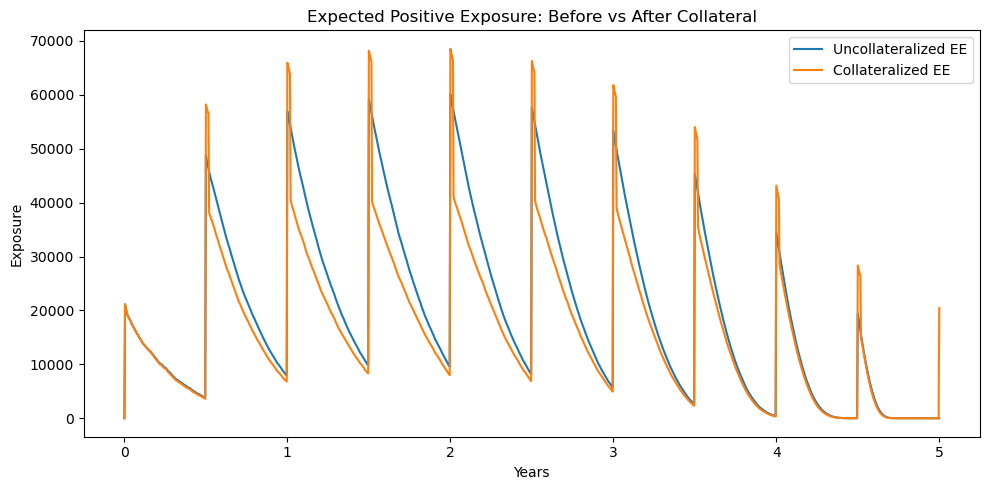

In [29]:
# ------------------------------------------------------------
# Plot uncollateralized vs collateralized positive exposure
# ------------------------------------------------------------
# Collateral should reduce expected exposure, but not eliminate it
# because of threshold, minimum transfer amount, and margin lag.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(hw_sim.time_grid, ee, label="Uncollateralized EE")
plt.plot(hw_sim.time_grid, coll_ee, label="Collateralized EE")
plt.title("Expected Positive Exposure: Before vs After Collateral")
plt.xlabel("Years")
plt.ylabel("Exposure")
plt.legend()
plt.tight_layout()
plt.show()

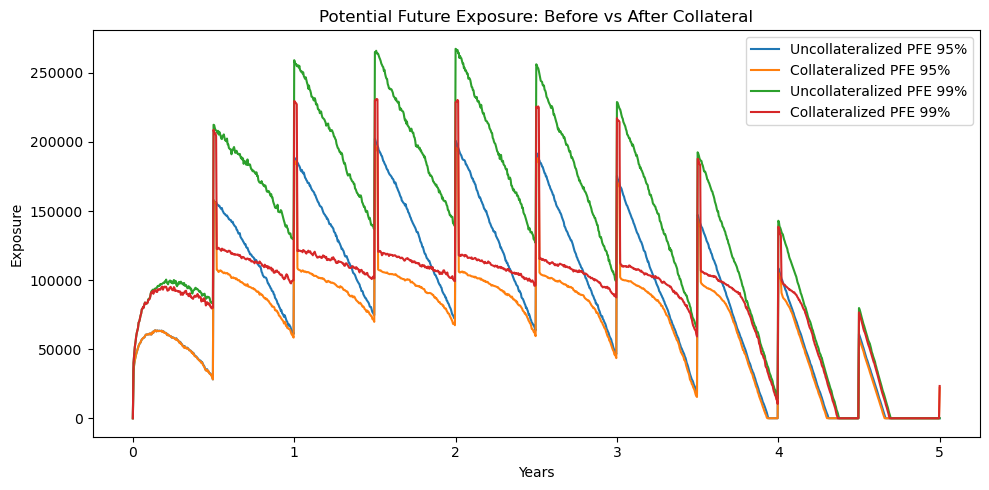

In [30]:
# ------------------------------------------------------------
# Plot uncollateralized vs collateralized PFE
# ------------------------------------------------------------
# PFE shows high-quantile future exposure. Collateral should reduce
# PFE, especially after the margin lag begins to matter.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(hw_sim.time_grid, pfe_95, label="Uncollateralized PFE 95%")
plt.plot(hw_sim.time_grid, coll_pfe_95, label="Collateralized PFE 95%")
plt.plot(hw_sim.time_grid, pfe_99, label="Uncollateralized PFE 99%")
plt.plot(hw_sim.time_grid, coll_pfe_99, label="Collateralized PFE 99%")
plt.title("Potential Future Exposure: Before vs After Collateral")
plt.xlabel("Years")
plt.ylabel("Exposure")
plt.legend()
plt.tight_layout()
plt.show()

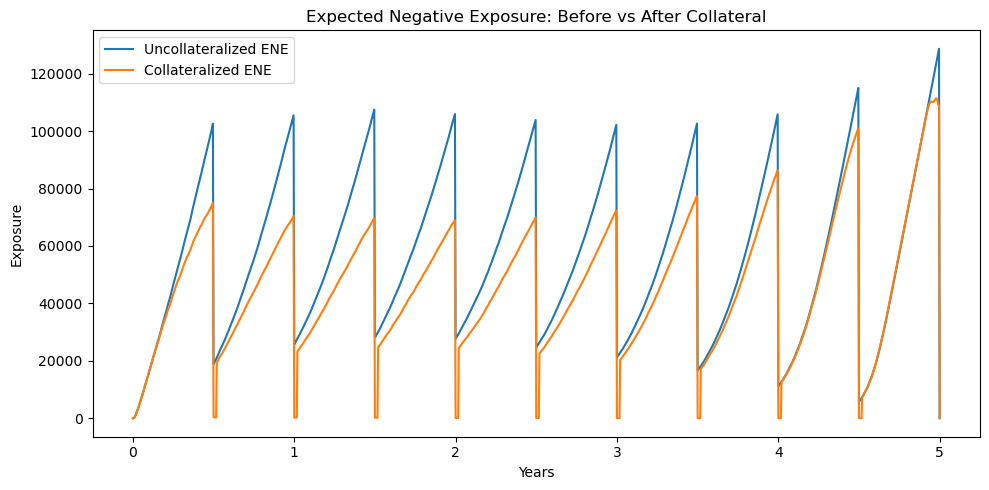

In [31]:
# ------------------------------------------------------------
# Plot uncollateralized vs collateralized negative exposure
# ------------------------------------------------------------
# Negative exposure will later feed DVA. Under a bilateral collateral
# agreement, collateral should reduce negative exposure too.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(hw_sim.time_grid, ene, label="Uncollateralized ENE")
plt.plot(hw_sim.time_grid, coll_ene, label="Collateralized ENE")
plt.title("Expected Negative Exposure: Before vs After Collateral")
plt.xlabel("Years")
plt.ylabel("Exposure")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# ------------------------------------------------------------
# Collateralized exposure summary table
# ------------------------------------------------------------
# This table will later feed the README and report.
# ------------------------------------------------------------

collateral_exposure_summary = pd.DataFrame([
    {
        "metric": "Average uncollateralized EE",
        "value": ee.mean(),
    },
    {
        "metric": "Average collateralized EE",
        "value": coll_ee.mean(),
    },
    {
        "metric": "Average uncollateralized ENE",
        "value": ene.mean(),
    },
    {
        "metric": "Average collateralized ENE",
        "value": coll_ene.mean(),
    },
    {
        "metric": "Peak uncollateralized PFE 95%",
        "value": pfe_95.max(),
    },
    {
        "metric": "Peak collateralized PFE 95%",
        "value": coll_pfe_95.max(),
    },
    {
        "metric": "Peak uncollateralized PFE 99%",
        "value": pfe_99.max(),
    },
    {
        "metric": "Peak collateralized PFE 99%",
        "value": coll_pfe_99.max(),
    },
])

collateral_exposure_summary

,metric,value
0,Average uncollateralized EE,19500.050482
1,Average collateralized EE,16603.194192
2,Average uncollateralized ENE,56792.348111
3,Average collateralized ENE,45832.652218
4,Peak uncollateralized PFE 95%,202340.970785
5,Peak collateralized PFE 95%,198506.084099
6,Peak uncollateralized PFE 99%,267424.118188
7,Peak collateralized PFE 99%,231106.029843


In [33]:
# ------------------------------------------------------------
# Perfect collateral sanity test
# ------------------------------------------------------------
# With zero threshold, zero MTA, and zero lag, collateral should
# almost fully eliminate positive and negative exposure.
# This checks that the margining implementation behaves correctly.
# ------------------------------------------------------------

perfect_agreement = CollateralAgreement(
    threshold=0,
    minimum_transfer_amount=0,
    margin_lag_steps=0,
    bilateral=True,
)

perfect_collateral = compute_collateral_balance(
    values=swap_values,
    agreement=perfect_agreement,
)

perfect_pos_exp = collateralized_positive_exposure(
    values=swap_values,
    collateral=perfect_collateral,
)

perfect_neg_exp = collateralized_negative_exposure(
    values=swap_values,
    collateral=perfect_collateral,
)

print(f"Max perfect collateral positive exposure: {perfect_pos_exp.max():,.8f}")
print(f"Max perfect collateral negative exposure: {perfect_neg_exp.max():,.8f}")

Max perfect collateral positive exposure: 0.00000000
Max perfect collateral negative exposure: 0.00000000


In [34]:
# ------------------------------------------------------------
# Collateral scenario comparison
# ------------------------------------------------------------
# We compare different collateral agreements to see how threshold
# and margin lag affect exposure. This is an early risk-management
# sensitivity analysis and will be useful later for CVA stress tests.
# ------------------------------------------------------------

collateral_scenarios = {
    "Uncollateralized": None,
    "Perfect collateral": CollateralAgreement(
        threshold=0,
        minimum_transfer_amount=0,
        margin_lag_steps=0,
        bilateral=True,
    ),
    "Base CSA": CollateralAgreement(
        threshold=100_000,
        minimum_transfer_amount=10_000,
        margin_lag_steps=5,
        bilateral=True,
    ),
    "High threshold": CollateralAgreement(
        threshold=250_000,
        minimum_transfer_amount=10_000,
        margin_lag_steps=5,
        bilateral=True,
    ),
    "Long margin lag": CollateralAgreement(
        threshold=100_000,
        minimum_transfer_amount=10_000,
        margin_lag_steps=10,
        bilateral=True,
    ),
}

rows = []

for scenario_name, agreement in collateral_scenarios.items():
    if agreement is None:
        scenario_pos = pos_exp
        scenario_neg = neg_exp
    else:
        scenario_collateral = compute_collateral_balance(
            values=swap_values,
            agreement=agreement,
        )

        scenario_pos = collateralized_positive_exposure(
            values=swap_values,
            collateral=scenario_collateral,
        )

        scenario_neg = collateralized_negative_exposure(
            values=swap_values,
            collateral=scenario_collateral,
        )

    scenario_ee = expected_exposure(scenario_pos)
    scenario_ene = expected_exposure(scenario_neg)
    scenario_pfe_95 = potential_future_exposure(scenario_pos, quantile=0.95)
    scenario_pfe_99 = potential_future_exposure(scenario_pos, quantile=0.99)

    rows.append({
        "scenario": scenario_name,
        "average_EE": scenario_ee.mean(),
        "average_ENE": scenario_ene.mean(),
        "peak_PFE_95": scenario_pfe_95.max(),
        "peak_PFE_99": scenario_pfe_99.max(),
    })

collateral_scenario_summary = pd.DataFrame(rows)
collateral_scenario_summary

,scenario,average_EE,average_ENE,peak_PFE_95,peak_PFE_99
0,Uncollateralized,19500.050482,56792.348111,202340.970785,267424.118188
1,Perfect collateral,0.000000,0.000000,0.000000,0.000000
2,Base CSA,16603.194192,45832.652218,198506.084099,231106.029843
3,High threshold,19413.770579,56295.635138,202123.035630,267216.990099
4,Long margin lag,16846.380709,46146.512547,195790.123565,230192.935674


## Collateral impact interpretation

The collateral agreement reduces both positive and negative exposure, but it does
not eliminate them because the agreement includes a threshold, a minimum transfer
amount, and a five-step margin lag.

The perfect-collateral sanity test confirms that the implementation behaves
correctly: when threshold, minimum transfer amount, and margin lag are all set to
zero, collateralized positive and negative exposure both collapse to zero.

Therefore, the remaining collateralized exposure in the base agreement is driven
by realistic collateral frictions rather than a coding error.

In [35]:
# ------------------------------------------------------------
# Import credit curve tools
# ------------------------------------------------------------
# These functions convert stylized credit spread scenarios into
# piecewise-constant hazard-rate curves, survival probabilities,
# and marginal default probabilities.
#
# These credit curves will later feed first-to-default CVA/DVA.
# ------------------------------------------------------------

from src.credit.hazard_curve import (
    load_credit_spread_scenarios,
    build_hazard_curve_from_spread_table,
    credit_curve_summary,
)

In [36]:
# ------------------------------------------------------------
# Load stylized credit spread scenarios
# ------------------------------------------------------------
# Single-name CDS curves are usually not freely available, so this
# project uses stylized spread curves. They are transparent inputs
# for demonstrating the CVA/DVA methodology.
#
# The loader converts bps columns into decimal spread columns.
# Example:
#   120 bps -> 0.0120
# ------------------------------------------------------------

credit_spreads = load_credit_spread_scenarios(
    PROJECT_ROOT / "data/raw/credit_spread_scenarios.csv"
)

credit_spreads.head()

,maturity_years,counterparty_base_bps,counterparty_stress_bps,self_base_bps,self_stress_bps,counterparty_base,counterparty_stress,self_base,self_stress
0,1,50,120,40,100,0.005,0.012,0.0040,0.010
1,3,80,180,65,150,0.008,0.018,0.0065,0.015
2,5,120,250,100,220,0.012,0.025,0.0100,0.022
3,7,150,320,130,280,0.015,0.032,0.0130,0.028
4,10,180,400,160,350,0.018,0.040,0.0160,0.035


In [37]:
# ------------------------------------------------------------
# Build base counterparty and own hazard curves
# ------------------------------------------------------------
# We use recovery_rate = 40% as a standard stylized assumption.
#
# Approximation:
#   hazard_rate ≈ credit_spread / (1 - recovery_rate)
#
# This is not full CDS bootstrapping, but it is transparent and
# sufficient for a first CVA/DVA engine.
# ------------------------------------------------------------

counterparty_recovery = 0.40
self_recovery = 0.40

counterparty_curve = build_hazard_curve_from_spread_table(
    spread_table=credit_spreads,
    spread_column="counterparty_base",
    recovery_rate=counterparty_recovery,
)

self_curve = build_hazard_curve_from_spread_table(
    spread_table=credit_spreads,
    spread_column="self_base",
    recovery_rate=self_recovery,
)

print("Counterparty hazard rates:", counterparty_curve.hazard_rates)
print("Self hazard rates:", self_curve.hazard_rates)

Counterparty hazard rates: [0.00833333 0.01333333 0.02       0.025      0.03      ]
Self hazard rates: [0.00666667 0.01083333 0.01666667 0.02166667 0.02666667]


In [38]:
# ------------------------------------------------------------
# Summarize survival and default probabilities on exposure grid
# ------------------------------------------------------------
# CVA and DVA are computed on the same time grid as exposure.
# This table gives Q(0,t), cumulative default probability, and
# marginal default probability for each future date.
# ------------------------------------------------------------

counterparty_credit_summary = credit_curve_summary(
    curve=counterparty_curve,
    time_grid=hw_sim.time_grid,
)

self_credit_summary = credit_curve_summary(
    curve=self_curve,
    time_grid=hw_sim.time_grid,
)

counterparty_credit_summary.head()

,time,hazard_rate,survival_probability,cumulative_default_probability,marginal_default_probability
0,0.000000,0.008333,1.000000,0.000000,0.000000
1,0.003968,0.008333,0.999967,0.000033,0.000033
2,0.007937,0.008333,0.999934,0.000066,0.000033
3,0.011905,0.008333,0.999901,0.000099,0.000033
4,0.015873,0.008333,0.999868,0.000132,0.000033


In [39]:
counterparty_credit_summary.tail()

,time,hazard_rate,survival_probability,cumulative_default_probability,marginal_default_probability
1256,4.984127,0.02,0.928038,0.071962,0.000074
1257,4.988095,0.02,0.927964,0.072036,0.000074
1258,4.992063,0.02,0.927891,0.072109,0.000074
1259,4.996032,0.02,0.927817,0.072183,0.000074
1260,5.000000,0.02,0.927743,0.072257,0.000074


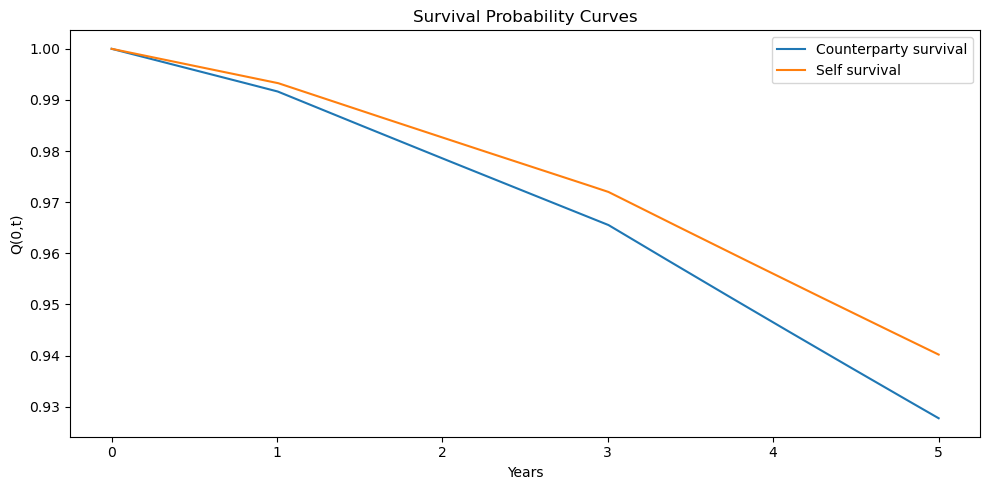

In [40]:
# ------------------------------------------------------------
# Plot survival probabilities
# ------------------------------------------------------------
# Survival probability Q(0,t) should decrease over time.
# The counterparty curve and self curve may differ because their
# credit spread assumptions differ.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(
    counterparty_credit_summary["time"],
    counterparty_credit_summary["survival_probability"],
    label="Counterparty survival"
)
plt.plot(
    self_credit_summary["time"],
    self_credit_summary["survival_probability"],
    label="Self survival"
)
plt.title("Survival Probability Curves")
plt.xlabel("Years")
plt.ylabel("Q(0,t)")
plt.legend()
plt.tight_layout()
plt.show()

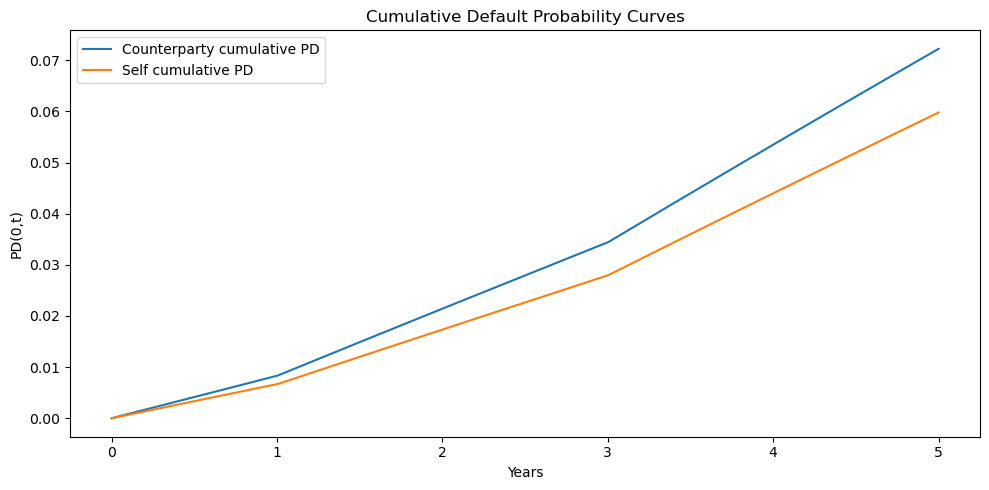

In [41]:
# ------------------------------------------------------------
# Plot cumulative default probabilities
# ------------------------------------------------------------
# Cumulative default probability is:
#   PD(0,t) = 1 - Q(0,t)
#
# It should increase over time.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(
    counterparty_credit_summary["time"],
    counterparty_credit_summary["cumulative_default_probability"],
    label="Counterparty cumulative PD"
)
plt.plot(
    self_credit_summary["time"],
    self_credit_summary["cumulative_default_probability"],
    label="Self cumulative PD"
)
plt.title("Cumulative Default Probability Curves")
plt.xlabel("Years")
plt.ylabel("PD(0,t)")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# ------------------------------------------------------------
# Credit curve sanity checks
# ------------------------------------------------------------
# We check that:
#   - survival starts at 1
#   - survival decreases over time
#   - cumulative PD increases over time
#   - marginal PDs are non-negative
# ------------------------------------------------------------

cp_survival = counterparty_credit_summary["survival_probability"].to_numpy()
cp_cum_pd = counterparty_credit_summary["cumulative_default_probability"].to_numpy()
cp_marginal_pd = counterparty_credit_summary["marginal_default_probability"].to_numpy()

print(f"Counterparty survival at t=0: {cp_survival[0]:.6f}")
print(f"Counterparty survival at final time: {cp_survival[-1]:.6f}")
print(f"Counterparty cumulative PD at final time: {cp_cum_pd[-1]:.6f}")
print(f"Minimum marginal PD: {cp_marginal_pd[1:].min():.10f}")
print(f"Maximum marginal PD: {cp_marginal_pd.max():.10f}")

Counterparty survival at t=0: 1.000000
Counterparty survival at final time: 0.927743
Counterparty cumulative PD at final time: 0.072257
Minimum marginal PD: 0.0000327949
Maximum marginal PD: 0.0000766323


In [43]:
# ------------------------------------------------------------
# Credit summary at key maturities
# ------------------------------------------------------------
# This compact table is useful for README/report documentation.
# ------------------------------------------------------------

key_times = np.array([1, 3, 5])

credit_key_summary = pd.DataFrame({
    "time": key_times,
    "counterparty_survival": counterparty_curve.survival_probability(key_times),
    "counterparty_cumulative_pd": 1 - counterparty_curve.survival_probability(key_times),
    "self_survival": self_curve.survival_probability(key_times),
    "self_cumulative_pd": 1 - self_curve.survival_probability(key_times),
})

credit_key_summary

,time,counterparty_survival,counterparty_cumulative_pd,self_survival,self_cumulative_pd
0,1,0.991701,0.008299,0.993356,0.006644
1,3,0.965605,0.034395,0.972064,0.027936
2,5,0.927743,0.072257,0.940196,0.059804


The credit curve uses piecewise-constant hazard rates inferred from stylized
credit spreads using the approximation \( \lambda \approx s/(1-R) \). This is
not full CDS bootstrapping, but it provides transparent survival and marginal
default probabilities for the CVA/DVA engine.

In [44]:
# ------------------------------------------------------------
# Import CVA/DVA tools
# ------------------------------------------------------------
# These functions combine collateralized exposure, discounting,
# survival probabilities, and marginal default probabilities to
# compute unilateral and first-to-default bilateral CVA/DVA.
# ------------------------------------------------------------

from src.xva.cva_dva import (
    compute_unilateral_cva,
    compute_unilateral_dva,
    compute_bilateral_first_to_default_cva_dva,
    xva_summary_table,
)

In [45]:
# ------------------------------------------------------------
# Compute unilateral collateralized CVA and DVA
# ------------------------------------------------------------
# Unilateral CVA ignores own default.
# Unilateral DVA ignores counterparty default.
#
# These are useful benchmark values before applying the bilateral
# first-to-default adjustment.
# ------------------------------------------------------------

unilateral_cva, unilateral_cva_detail = compute_unilateral_cva(
    time_grid=hw_sim.time_grid,
    expected_positive_exposure=coll_ee,
    counterparty_curve=counterparty_curve,
    discount_curve=curve,
)

unilateral_dva, unilateral_dva_detail = compute_unilateral_dva(
    time_grid=hw_sim.time_grid,
    expected_negative_exposure=coll_ene,
    self_curve=self_curve,
    discount_curve=curve,
)

print(f"Unilateral CVA: {unilateral_cva:,.2f}")
print(f"Unilateral DVA: {unilateral_dva:,.2f}")

Unilateral CVA: 644.45
Unilateral DVA: 1,552.89


In [46]:
risk_free_value = swap_values[:, 0].mean()

In [47]:
# ------------------------------------------------------------
# Compute bilateral first-to-default CVA/DVA
# ------------------------------------------------------------
# The first-to-default adjustment prevents double counting by
# weighting each party's default contribution by survival of the
# other party.
#
# Adjusted value:
#   V_adjusted = V_risk_free - CVA_FTD + DVA_FTD
# ------------------------------------------------------------

risk_free_value = float(swap_values[:, 0].mean())

xva_result = compute_bilateral_first_to_default_cva_dva(
    time_grid=hw_sim.time_grid,
    expected_positive_exposure=coll_ee,
    expected_negative_exposure=coll_ene,
    counterparty_curve=counterparty_curve,
    self_curve=self_curve,
    discount_curve=curve,
    risk_free_value=risk_free_value,
)

xva_summary = xva_summary_table(xva_result)
xva_summary

,metric,value
0,CVA,630.333128
1,DVA,1492.871910
2,Net XVA adjustment (-CVA + DVA),862.538782
3,Risk-free value,0.000000
4,CVA/DVA-adjusted value,862.538782


In [48]:
# ------------------------------------------------------------
# Inspect first rows of CVA/DVA contribution table
# ------------------------------------------------------------
# Each row corresponds to one time interval [t_start, t_end].
# Contributions are small interval losses that sum to total CVA/DVA.
# ------------------------------------------------------------

xva_result.detail.head()

,t_start,t_end,discount_factor,collateralized_EE,collateralized_ENE,counterparty_survival,self_survival,counterparty_marginal_pd,self_marginal_pd,cva_contribution,dva_contribution
0,0.000000,0.003968,0.999913,21141.851333,12.139762,0.999967,0.999974,0.000033,0.000026,0.419427,0.000193
1,0.003968,0.007937,0.999826,20466.926499,154.029769,0.999934,0.999947,0.000033,0.000026,0.405977,0.002444
2,0.007937,0.011905,0.999738,19994.243778,459.632994,0.999901,0.999921,0.000033,0.000026,0.396543,0.007293
3,0.011905,0.015873,0.999651,19541.467575,925.920706,0.999868,0.999894,0.000033,0.000026,0.387506,0.014689
4,0.015873,0.019841,0.999563,19051.803278,1471.482702,0.999835,0.999868,0.000033,0.000026,0.377741,0.023340


In [49]:
# ------------------------------------------------------------
# Largest CVA contribution periods
# ------------------------------------------------------------
# This shows where counterparty credit loss is concentrated across
# the life of the swap.
# ------------------------------------------------------------

xva_result.detail.sort_values(
    "cva_contribution",
    ascending=False,
).head(10)

,t_start,t_end,discount_factor,collateralized_EE,collateralized_ENE,counterparty_survival,self_survival,counterparty_marginal_pd,self_marginal_pd,cva_contribution,dva_contribution
756,3.000000,3.003968,0.927690,61220.422656,32.030274,0.965529,0.972000,0.000077,0.000064,2.538217,0.001107
757,3.003968,3.007937,0.927595,60650.044237,35.724966,0.965452,0.971936,0.000077,0.000064,2.513945,0.001234
758,3.007937,3.011905,0.927500,60169.980562,35.050671,0.965376,0.971871,0.000077,0.000064,2.493428,0.001210
759,3.011905,3.015873,0.927405,59615.749676,39.461619,0.965299,0.971807,0.000077,0.000064,2.469847,0.001362
881,3.496032,3.500000,0.915740,54016.293711,10.949567,0.955997,0.963997,0.000076,0.000064,2.170839,0.000367
882,3.500000,3.503968,0.915644,53402.223051,10.652023,0.955922,0.963934,0.000076,0.000064,2.145623,0.000357
883,3.503968,3.507937,0.915548,52785.168810,6.162499,0.955846,0.963870,0.000076,0.000064,2.120300,0.000206
884,3.507937,3.511905,0.915452,52236.612327,9.147811,0.955770,0.963806,0.000076,0.000064,2.097740,0.000306
885,3.511905,3.515873,0.915356,51719.700168,8.341694,0.955694,0.963742,0.000076,0.000064,2.076462,0.000279
377,1.496032,1.500000,0.963699,68152.336307,181.705843,0.985112,0.987989,0.000052,0.000042,2.029369,0.004396


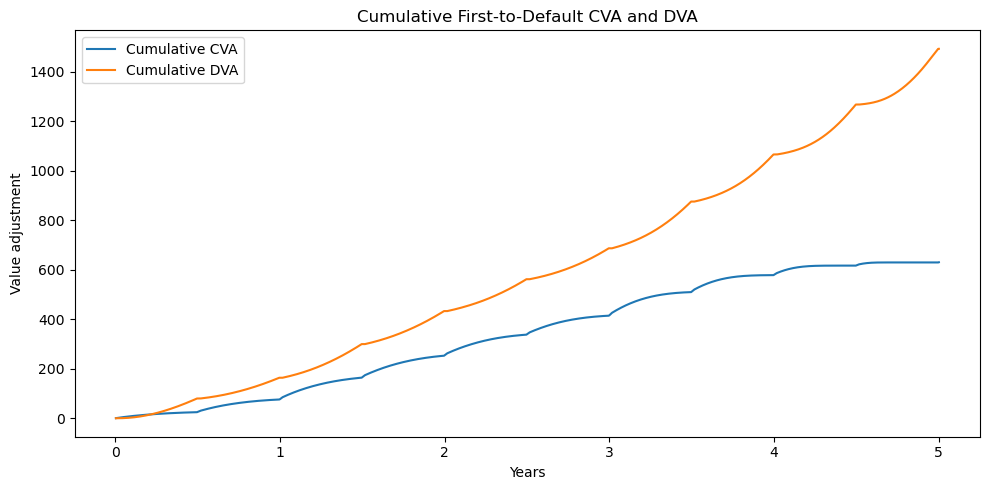

In [50]:
# ------------------------------------------------------------
# Plot cumulative CVA and DVA contributions
# ------------------------------------------------------------
# This shows how the valuation adjustments build up over the life
# of the swap.
# ------------------------------------------------------------

xva_detail = xva_result.detail.copy()

xva_detail["cumulative_cva"] = xva_detail["cva_contribution"].cumsum()
xva_detail["cumulative_dva"] = xva_detail["dva_contribution"].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(xva_detail["t_end"], xva_detail["cumulative_cva"], label="Cumulative CVA")
plt.plot(xva_detail["t_end"], xva_detail["cumulative_dva"], label="Cumulative DVA")
plt.title("Cumulative First-to-Default CVA and DVA")
plt.xlabel("Years")
plt.ylabel("Value adjustment")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
# ------------------------------------------------------------
# Compare unilateral and first-to-default CVA/DVA
# ------------------------------------------------------------
# First-to-default values should usually be slightly lower than
# unilateral values because each side's contribution is weighted
# by survival of the other party.
# ------------------------------------------------------------

comparison_rows = [
    {
        "metric": "Unilateral CVA",
        "value": unilateral_cva,
    },
    {
        "metric": "First-to-default CVA",
        "value": xva_result.cva,
    },
    {
        "metric": "Unilateral DVA",
        "value": unilateral_dva,
    },
    {
        "metric": "First-to-default DVA",
        "value": xva_result.dva,
    },
    {
        "metric": "FTD CVA reduction",
        "value": unilateral_cva - xva_result.cva,
    },
    {
        "metric": "FTD DVA reduction",
        "value": unilateral_dva - xva_result.dva,
    },
]

xva_comparison = pd.DataFrame(comparison_rows)
xva_comparison

,metric,value
0,Unilateral CVA,644.449409
1,First-to-default CVA,630.333128
2,Unilateral DVA,1552.889969
3,First-to-default DVA,1492.871910
4,FTD CVA reduction,14.116281
5,FTD DVA reduction,60.018059


In [52]:
# ------------------------------------------------------------
# XVA consistency checks
# ------------------------------------------------------------
# These checks confirm that:
#   - first-to-default CVA is below unilateral CVA
#   - first-to-default DVA is below unilateral DVA
#   - adjusted value equals risk-free value - CVA + DVA
# ------------------------------------------------------------

print("FTD CVA <= unilateral CVA:", xva_result.cva <= unilateral_cva)
print("FTD DVA <= unilateral DVA:", xva_result.dva <= unilateral_dva)

recomputed_adjusted_value = (
    risk_free_value
    - xva_result.cva
    + xva_result.dva
)

print(
    "Adjusted value check:",
    np.isclose(xva_result.adjusted_value, recomputed_adjusted_value),
)

FTD CVA <= unilateral CVA: True
FTD DVA <= unilateral DVA: True
Adjusted value check: True


In [53]:
# ------------------------------------------------------------
# Stress scenario engine
# ------------------------------------------------------------
# This section compares CVA/DVA under different credit and collateral
# assumptions.
#
# The exposure simulation itself is unchanged:
#   swap_values = simulated risk-free mark-to-market values
#
# For each scenario, we change:
#   - counterparty credit spread curve
#   - own/self credit spread curve
#   - collateral agreement
#
# Then we recompute:
#   - collateralized EE / ENE
#   - bilateral first-to-default CVA / DVA
#   - adjusted value
# ------------------------------------------------------------

def run_xva_scenario(
    scenario_name,
    counterparty_spread_column,
    self_spread_column,
    collateral_agreement,
    credit_spreads,
    swap_values,
    time_grid,
    discount_curve,
    risk_free_value,
    recovery_rate=0.40,
):
    """
    Run one XVA scenario.

    Parameters
    ----------
    scenario_name:
        Descriptive scenario name.

    counterparty_spread_column:
        Column name in credit_spreads used for counterparty spreads.
        Example: 'counterparty_base' or 'counterparty_stress'.

    self_spread_column:
        Column name in credit_spreads used for own/self spreads.
        Example: 'self_base' or 'self_stress'.

    collateral_agreement:
        CollateralAgreement object defining threshold, MTA, lag, and bilateral rule.

    credit_spreads:
        DataFrame containing spread curves.

    swap_values:
        Simulated mark-to-market values, shape (n_paths, n_times).

    time_grid:
        Simulation time grid.

    discount_curve:
        Initial zero curve used for discounting.

    risk_free_value:
        Initial risk-free value of the swap.

    recovery_rate:
        Recovery rate used for both counterparties in this simplified setup.

    Returns
    -------
    dict
        Scenario-level XVA summary.
    """

    # Build counterparty hazard curve for this scenario.
    scenario_counterparty_curve = build_hazard_curve_from_spread_table(
        spread_table=credit_spreads,
        spread_column=counterparty_spread_column,
        recovery_rate=recovery_rate,
    )

    # Build own/default hazard curve for this scenario.
    scenario_self_curve = build_hazard_curve_from_spread_table(
        spread_table=credit_spreads,
        spread_column=self_spread_column,
        recovery_rate=recovery_rate,
    )

    # Compute scenario-specific collateral balances.
    scenario_collateral = compute_collateral_balance(
        values=swap_values,
        agreement=collateral_agreement,
    )

    # Compute scenario-specific collateralized positive exposure.
    scenario_coll_pos_exp = collateralized_positive_exposure(
        values=swap_values,
        collateral=scenario_collateral,
    )

    # Compute scenario-specific collateralized negative exposure.
    scenario_coll_neg_exp = collateralized_negative_exposure(
        values=swap_values,
        collateral=scenario_collateral,
    )

    # Convert pathwise exposures into expected exposure profiles.
    scenario_coll_ee = expected_exposure(scenario_coll_pos_exp)
    scenario_coll_ene = expected_exposure(scenario_coll_neg_exp)

    # Compute tail exposure metrics for reporting.
    scenario_coll_pfe_95 = potential_future_exposure(
        scenario_coll_pos_exp,
        quantile=0.95,
    )

    scenario_coll_pfe_99 = potential_future_exposure(
        scenario_coll_pos_exp,
        quantile=0.99,
    )

    # Compute first-to-default bilateral CVA/DVA.
    scenario_xva = compute_bilateral_first_to_default_cva_dva(
        time_grid=time_grid,
        expected_positive_exposure=scenario_coll_ee,
        expected_negative_exposure=scenario_coll_ene,
        counterparty_curve=scenario_counterparty_curve,
        self_curve=scenario_self_curve,
        discount_curve=discount_curve,
        risk_free_value=risk_free_value,
    )

    # Return one compact scenario row.
    return {
        "scenario": scenario_name,
        "counterparty_spread_curve": counterparty_spread_column,
        "self_spread_curve": self_spread_column,
        "threshold": collateral_agreement.threshold,
        "minimum_transfer_amount": collateral_agreement.minimum_transfer_amount,
        "margin_lag_steps": collateral_agreement.margin_lag_steps,
        "average_collateralized_EE": scenario_coll_ee.mean(),
        "average_collateralized_ENE": scenario_coll_ene.mean(),
        "peak_collateralized_PFE_95": scenario_coll_pfe_95.max(),
        "peak_collateralized_PFE_99": scenario_coll_pfe_99.max(),
        "CVA": scenario_xva.cva,
        "DVA": scenario_xva.dva,
        "net_xva_adjustment": -scenario_xva.cva + scenario_xva.dva,
        "adjusted_value": scenario_xva.adjusted_value,
    }

In [54]:
# ------------------------------------------------------------
# Define XVA stress scenarios
# ------------------------------------------------------------
# Base CSA:
#   threshold = 100k
#   MTA = 10k
#   lag = 5 steps
#
# Stressed CSA:
#   threshold = 250k
#   MTA = 25k
#   lag = 10 steps
#
# The stressed CSA leaves more exposure unsecured and makes collateral
# slower to respond to market moves.
# ------------------------------------------------------------

base_csa = CollateralAgreement(
    threshold=100_000,
    minimum_transfer_amount=10_000,
    margin_lag_steps=5,
    bilateral=True,
)

stressed_csa = CollateralAgreement(
    threshold=250_000,
    minimum_transfer_amount=25_000,
    margin_lag_steps=10,
    bilateral=True,
)

xva_scenarios = [
    {
        "scenario_name": "Base",
        "counterparty_spread_column": "counterparty_base",
        "self_spread_column": "self_base",
        "collateral_agreement": base_csa,
    },
    {
        "scenario_name": "Counterparty credit stress",
        "counterparty_spread_column": "counterparty_stress",
        "self_spread_column": "self_base",
        "collateral_agreement": base_csa,
    },
    {
        "scenario_name": "Self credit stress",
        "counterparty_spread_column": "counterparty_base",
        "self_spread_column": "self_stress",
        "collateral_agreement": base_csa,
    },
    {
        "scenario_name": "Joint credit stress",
        "counterparty_spread_column": "counterparty_stress",
        "self_spread_column": "self_stress",
        "collateral_agreement": base_csa,
    },
    {
        "scenario_name": "Collateral stress",
        "counterparty_spread_column": "counterparty_base",
        "self_spread_column": "self_base",
        "collateral_agreement": stressed_csa,
    },
    {
        "scenario_name": "Joint credit + collateral stress",
        "counterparty_spread_column": "counterparty_stress",
        "self_spread_column": "self_stress",
        "collateral_agreement": stressed_csa,
    },
]

In [55]:
# ------------------------------------------------------------
# Run all XVA stress scenarios
# ------------------------------------------------------------
# This loops through the scenario definitions, recomputes credit
# curves and collateralized exposures, and returns a compact table.
# ------------------------------------------------------------

scenario_rows = []

for scenario in xva_scenarios:
    row = run_xva_scenario(
        scenario_name=scenario["scenario_name"],
        counterparty_spread_column=scenario["counterparty_spread_column"],
        self_spread_column=scenario["self_spread_column"],
        collateral_agreement=scenario["collateral_agreement"],
        credit_spreads=credit_spreads,
        swap_values=swap_values,
        time_grid=hw_sim.time_grid,
        discount_curve=curve,
        risk_free_value=risk_free_value,
        recovery_rate=0.40,
    )

    scenario_rows.append(row)

xva_stress_summary = pd.DataFrame(scenario_rows)

xva_stress_summary

,scenario,counterparty_spread_curve,self_spread_curve,threshold,minimum_transfer_amount,margin_lag_steps,average_collateralized_EE,average_collateralized_ENE,peak_collateralized_PFE_95,peak_collateralized_PFE_99,CVA,DVA,net_xva_adjustment,adjusted_value
0,Base,counterparty_base,self_base,100000,10000,5,16603.194192,45832.652218,198506.084099,231106.029843,630.333128,1492.871910,862.538782,862.538782
1,Counterparty credit stress,counterparty_stress,self_base,100000,10000,5,16603.194192,45832.652218,198506.084099,231106.029843,1348.226957,1423.181986,74.955028,74.955028
2,Self credit stress,counterparty_base,self_stress,100000,10000,5,16603.194192,45832.652218,198506.084099,231106.029843,611.970048,3254.124966,2642.154918,2642.154918
3,Joint credit stress,counterparty_stress,self_stress,100000,10000,5,16603.194192,45832.652218,198506.084099,231106.029843,1310.311182,3106.991560,1796.680378,1796.680378
4,Collateral stress,counterparty_base,self_base,250000,25000,10,19367.043712,56369.794787,202123.035630,266432.788054,733.660603,1810.141928,1076.481325,1076.481325
5,Joint credit + collateral stress,counterparty_stress,self_stress,250000,25000,10,19367.043712,56369.794787,202123.035630,266432.788054,1528.961100,3792.900878,2263.939778,2263.939778


In [56]:
# ------------------------------------------------------------
# Compact XVA stress summary
# ------------------------------------------------------------
# This table focuses on the main valuation outputs.
# ------------------------------------------------------------

xva_stress_compact = xva_stress_summary[
    [
        "scenario",
        "average_collateralized_EE",
        "average_collateralized_ENE",
        "peak_collateralized_PFE_99",
        "CVA",
        "DVA",
        "net_xva_adjustment",
        "adjusted_value",
    ]
].copy()

xva_stress_compact

,scenario,average_collateralized_EE,average_collateralized_ENE,peak_collateralized_PFE_99,CVA,DVA,net_xva_adjustment,adjusted_value
0,Base,16603.194192,45832.652218,231106.029843,630.333128,1492.871910,862.538782,862.538782
1,Counterparty credit stress,16603.194192,45832.652218,231106.029843,1348.226957,1423.181986,74.955028,74.955028
2,Self credit stress,16603.194192,45832.652218,231106.029843,611.970048,3254.124966,2642.154918,2642.154918
3,Joint credit stress,16603.194192,45832.652218,231106.029843,1310.311182,3106.991560,1796.680378,1796.680378
4,Collateral stress,19367.043712,56369.794787,266432.788054,733.660603,1810.141928,1076.481325,1076.481325
5,Joint credit + collateral stress,19367.043712,56369.794787,266432.788054,1528.961100,3792.900878,2263.939778,2263.939778


In [57]:
# ------------------------------------------------------------
# Stress impacts relative to base scenario
# ------------------------------------------------------------
# This shows how much each stress scenario changes CVA, DVA, and
# adjusted value relative to the base case.
# ------------------------------------------------------------

base_row = xva_stress_summary.loc[
    xva_stress_summary["scenario"] == "Base"
].iloc[0]

xva_stress_impacts = xva_stress_summary.copy()

xva_stress_impacts["delta_CVA_vs_base"] = (
    xva_stress_impacts["CVA"] - base_row["CVA"]
)

xva_stress_impacts["delta_DVA_vs_base"] = (
    xva_stress_impacts["DVA"] - base_row["DVA"]
)

xva_stress_impacts["delta_net_xva_vs_base"] = (
    xva_stress_impacts["net_xva_adjustment"]
    - base_row["net_xva_adjustment"]
)

xva_stress_impacts["delta_adjusted_value_vs_base"] = (
    xva_stress_impacts["adjusted_value"]
    - base_row["adjusted_value"]
)

xva_stress_impacts_compact = xva_stress_impacts[
    [
        "scenario",
        "delta_CVA_vs_base",
        "delta_DVA_vs_base",
        "delta_net_xva_vs_base",
        "delta_adjusted_value_vs_base",
    ]
].copy()

xva_stress_impacts_compact

,scenario,delta_CVA_vs_base,delta_DVA_vs_base,delta_net_xva_vs_base,delta_adjusted_value_vs_base
0,Base,0.000000,0.000000,0.000000,0.000000
1,Counterparty credit stress,717.893830,-69.689924,-787.583754,-787.583754
2,Self credit stress,-18.363080,1761.253056,1779.616136,1779.616136
3,Joint credit stress,679.978054,1614.119650,934.141595,934.141595
4,Collateral stress,103.327476,317.270018,213.942543,213.942543
5,Joint credit + collateral stress,898.627973,2300.028968,1401.400995,1401.400995


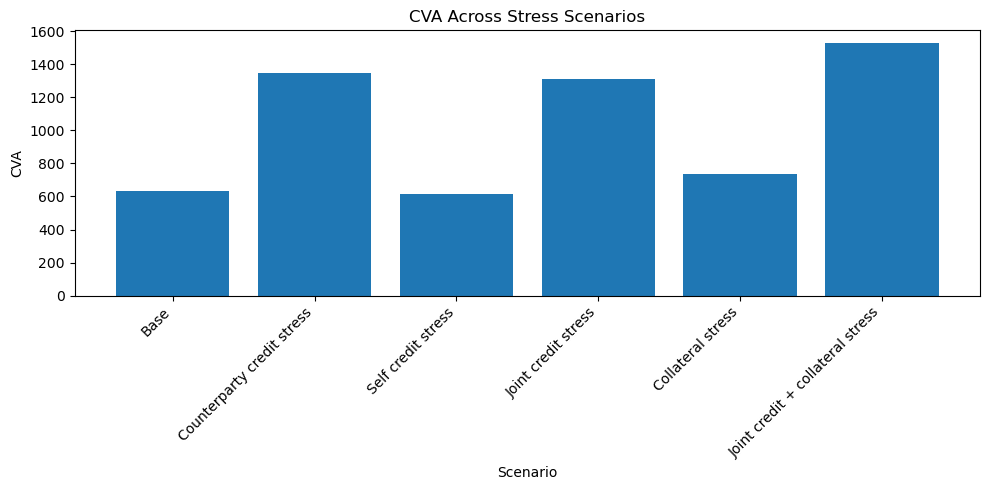

In [58]:
# ------------------------------------------------------------
# Plot CVA across stress scenarios
# ------------------------------------------------------------
# Counterparty credit stress should increase CVA because the
# counterparty marginal default probabilities become larger.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.bar(xva_stress_compact["scenario"], xva_stress_compact["CVA"])
plt.title("CVA Across Stress Scenarios")
plt.xlabel("Scenario")
plt.ylabel("CVA")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

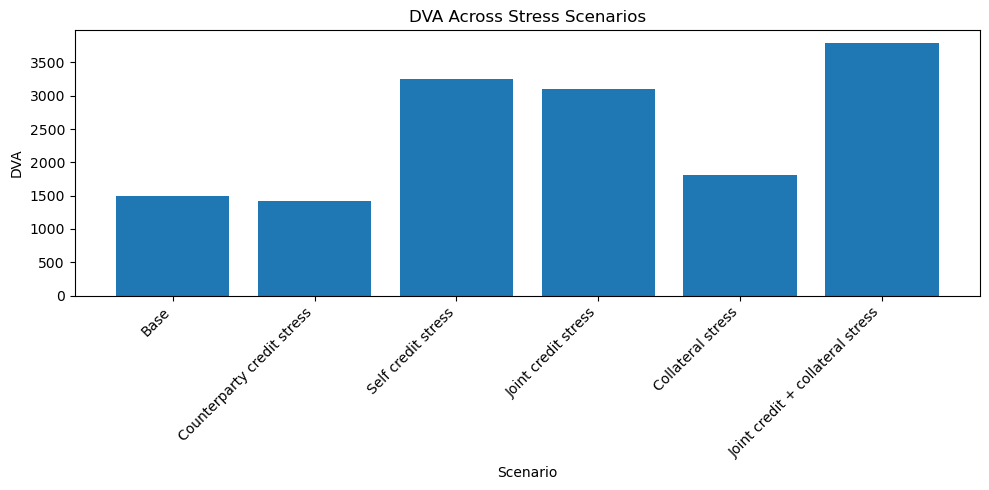

In [59]:
# ------------------------------------------------------------
# Plot DVA across stress scenarios
# ------------------------------------------------------------
# Self credit stress should increase DVA because own marginal
# default probabilities become larger.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.bar(xva_stress_compact["scenario"], xva_stress_compact["DVA"])
plt.title("DVA Across Stress Scenarios")
plt.xlabel("Scenario")
plt.ylabel("DVA")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

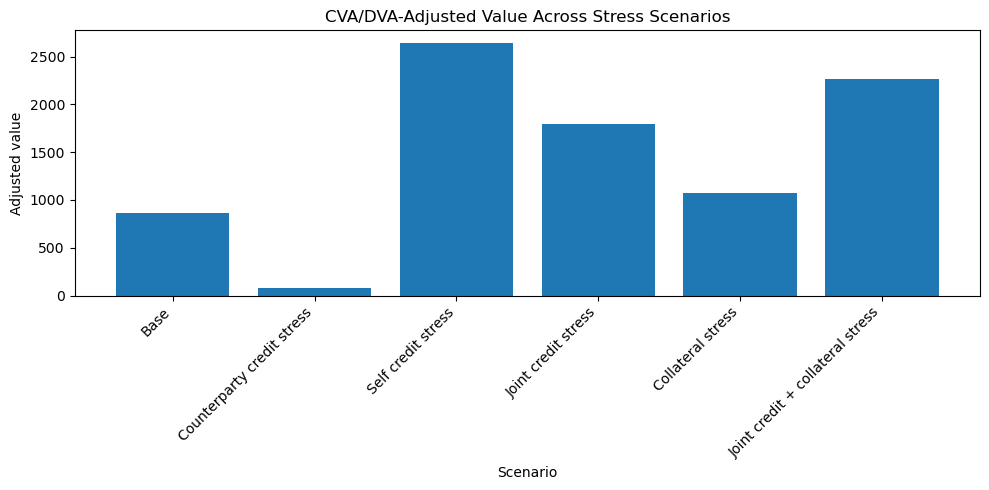

In [60]:
# ------------------------------------------------------------
# Plot adjusted value across stress scenarios
# ------------------------------------------------------------
# Adjusted value combines both effects:
#
#   V_adjusted = V_risk_free - CVA + DVA
#
# Scenarios with larger DVA may increase adjusted value, while
# scenarios with larger CVA may reduce it.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.bar(
    xva_stress_compact["scenario"],
    xva_stress_compact["adjusted_value"],
)
plt.title("CVA/DVA-Adjusted Value Across Stress Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Adjusted value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [61]:
# ------------------------------------------------------------
# Stress scenario sanity checks
# ------------------------------------------------------------
# These checks confirm that the main directional effects behave
# as expected.
# ------------------------------------------------------------

base = xva_stress_summary.loc[
    xva_stress_summary["scenario"] == "Base"
].iloc[0]

cp_stress = xva_stress_summary.loc[
    xva_stress_summary["scenario"] == "Counterparty credit stress"
].iloc[0]

self_stress = xva_stress_summary.loc[
    xva_stress_summary["scenario"] == "Self credit stress"
].iloc[0]

coll_stress = xva_stress_summary.loc[
    xva_stress_summary["scenario"] == "Collateral stress"
].iloc[0]

print("Counterparty stress increases CVA:", cp_stress["CVA"] > base["CVA"])
print("Self stress increases DVA:", self_stress["DVA"] > base["DVA"])
print("Collateral stress increases collateralized EE:", coll_stress["average_collateralized_EE"] > base["average_collateralized_EE"])
print("Collateral stress increases collateralized ENE:", coll_stress["average_collateralized_ENE"] > base["average_collateralized_ENE"])

Counterparty stress increases CVA: True
Self stress increases DVA: True
Collateral stress increases collateralized EE: True
Collateral stress increases collateralized ENE: True


### First-to-default stress effect

Under first-to-default bilateral CVA/DVA, stressing one party's credit curve can
also reduce the other party's valuation adjustment.

Counterparty credit stress increases counterparty marginal default probabilities,
which raises CVA. However, it also lowers counterparty survival probabilities,
which can reduce DVA because DVA is conditional on the counterparty surviving
until the bank's default.

Similarly, self credit stress increases own marginal default probabilities,
which raises DVA. However, it lowers own survival probabilities, which can
reduce CVA because CVA is conditional on the bank surviving until the
counterparty's default.

This cross-effect is a consequence of the first-to-default adjustment, not a
coding error.

In [62]:
# ------------------------------------------------------------
# Import wrong-way risk tools
# ------------------------------------------------------------
# These functions simulate path-dependent counterparty hazard rates
# correlated with the interest-rate shocks and compute CVA using
# E[exposure * pathwise default probability].
# ------------------------------------------------------------

from src.xva.wrong_way_risk import compute_wrong_way_cva

In [63]:
# ------------------------------------------------------------
# Compute wrong-way risk CVA
# ------------------------------------------------------------
# We start with positive correlation between rate shocks and
# counterparty credit intensity shocks.
#
# Important:
#   This produces WWR only if exposure tends to rise in the same
#   states where the correlated credit intensity rises.
# ------------------------------------------------------------

wwr_result = compute_wrong_way_cva(
    time_grid=hw_sim.time_grid,
    collateralized_positive_exposure_paths=coll_pos_exp,
    counterparty_curve=counterparty_curve,
    self_curve=self_curve,
    discount_curve=curve,
    rate_shocks=hw_sim.shocks,
    base_cva=xva_result.cva,
    hazard_volatility=1.0,
    correlation=0.5,
    seed=42,
)

wwr_summary = pd.DataFrame([
    {
        "metric": "Base first-to-default CVA",
        "value": wwr_result.base_cva,
    },
    {
        "metric": "Wrong-way-risk CVA",
        "value": wwr_result.wwr_cva,
    },
    {
        "metric": "Incremental WWR CVA",
        "value": wwr_result.incremental_wwr_cva,
    },
    {
        "metric": "Relative WWR impact",
        "value": wwr_result.relative_wwr_impact,
    },
])

wwr_summary

,metric,value
0,Base first-to-default CVA,630.333128
1,Wrong-way-risk CVA,635.326942
2,Incremental WWR CVA,4.993815
3,Relative WWR impact,0.007923


In [64]:
# ------------------------------------------------------------
# Wrong-way risk correlation sensitivity
# ------------------------------------------------------------
# We compute CVA under different correlations between rate shocks
# and counterparty credit intensity shocks.
#
# Positive/negative effects depend on whether exposure rises when
# rate shocks rise or fall.
# ------------------------------------------------------------

wwr_correlations = [-0.75, -0.50, -0.25, 0.00, 0.25, 0.50, 0.75]

wwr_rows = []

for rho in wwr_correlations:
    result = compute_wrong_way_cva(
        time_grid=hw_sim.time_grid,
        collateralized_positive_exposure_paths=coll_pos_exp,
        counterparty_curve=counterparty_curve,
        self_curve=self_curve,
        discount_curve=curve,
        rate_shocks=hw_sim.shocks,
        base_cva=xva_result.cva,
        hazard_volatility=1.0,
        correlation=rho,
        seed=42,
    )

    wwr_rows.append({
        "correlation": rho,
        "base_CVA": result.base_cva,
        "WWR_CVA": result.wwr_cva,
        "incremental_WWR_CVA": result.incremental_wwr_cva,
        "relative_WWR_impact": result.relative_wwr_impact,
    })

wwr_correlation_summary = pd.DataFrame(wwr_rows)
wwr_correlation_summary

,correlation,base_CVA,WWR_CVA,incremental_WWR_CVA,relative_WWR_impact
0,-0.75,630.333128,627.195432,-3.137696,-0.004978
1,-0.50,630.333128,629.176479,-1.156649,-0.001835
2,-0.25,630.333128,631.059708,0.726581,0.001153
3,0.00,630.333128,632.787038,2.453910,0.003893
4,0.25,630.333128,634.261018,3.927890,0.006231
5,0.50,630.333128,635.326942,4.993815,0.007923
6,0.75,630.333128,635.665554,5.332427,0.008460


In [65]:
# ------------------------------------------------------------
# Wrong-way risk impact relative to zero-correlation stochastic intensity
# ------------------------------------------------------------
# The deterministic base CVA and the rho = 0 stochastic-intensity CVA
# are not identical because the WWR model makes hazard rates stochastic.
#
# To isolate the effect of correlation, compare each CVA to the
# rho = 0 case:
#
#   pure correlation effect = CVA(rho) - CVA(rho=0)
# ------------------------------------------------------------

zero_corr_cva = wwr_correlation_summary.loc[
    wwr_correlation_summary["correlation"] == 0.00,
    "WWR_CVA",
].iloc[0]

wwr_correlation_summary["incremental_vs_zero_corr"] = (
    wwr_correlation_summary["WWR_CVA"] - zero_corr_cva
)

wwr_correlation_summary["relative_vs_zero_corr"] = (
    wwr_correlation_summary["incremental_vs_zero_corr"] / zero_corr_cva
)

wwr_correlation_summary

,correlation,base_CVA,WWR_CVA,incremental_WWR_CVA,relative_WWR_impact,incremental_vs_zero_corr,relative_vs_zero_corr
0,-0.75,630.333128,627.195432,-3.137696,-0.004978,-5.591606,-0.008836
1,-0.50,630.333128,629.176479,-1.156649,-0.001835,-3.610559,-0.005706
2,-0.25,630.333128,631.059708,0.726581,0.001153,-1.727329,-0.002730
3,0.00,630.333128,632.787038,2.453910,0.003893,0.000000,0.000000
4,0.25,630.333128,634.261018,3.927890,0.006231,1.473980,0.002329
5,0.50,630.333128,635.326942,4.993815,0.007923,2.539905,0.004014
6,0.75,630.333128,635.665554,5.332427,0.008460,2.878517,0.004549


### Wrong-way risk correlation interpretation

The deterministic base CVA is \(630.33\). When counterparty hazard rates are
made stochastic but uncorrelated with rate shocks, CVA becomes \(632.79\). This
difference reflects stochastic-intensity effects rather than pure wrong-way
risk.

To isolate the correlation-driven wrong-way risk effect, we compare each
scenario against the zero-correlation stochastic-intensity case:

\[
\Delta CVA_{\rho}
=
CVA(\rho)-CVA(0)
\]

The results show that negative correlations reduce CVA relative to the
zero-correlation case, producing right-way risk. Positive correlations increase
CVA, producing wrong-way risk. For \(\rho=0.50\), the pure correlation effect is
approximately \(+2.54\), or \(+0.40\%\) relative to the zero-correlation
stochastic-intensity CVA.

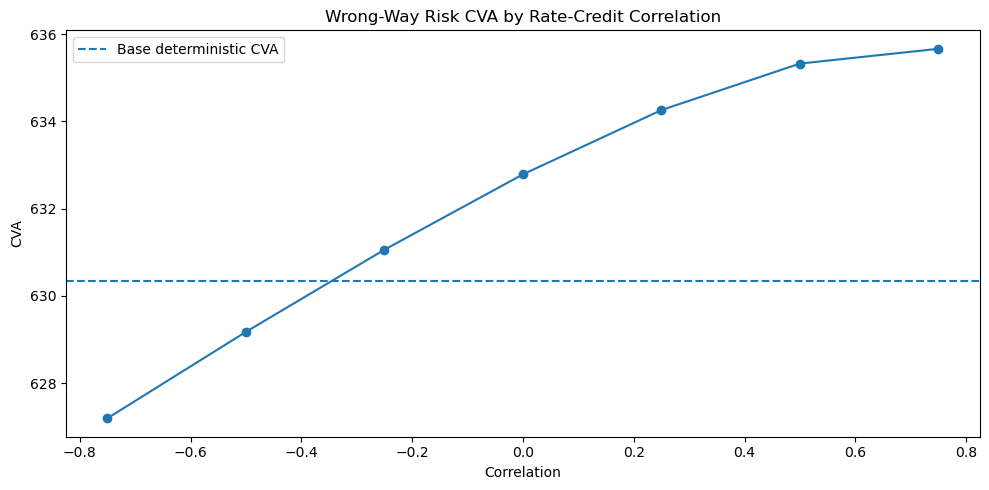

In [66]:
# ------------------------------------------------------------
# Plot wrong-way risk CVA by correlation
# ------------------------------------------------------------
# This shows whether CVA increases or decreases as counterparty
# credit intensity becomes more correlated with the rate shocks.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(
    wwr_correlation_summary["correlation"],
    wwr_correlation_summary["WWR_CVA"],
    marker="o",
)
plt.axhline(
    xva_result.cva,
    linestyle="--",
    label="Base deterministic CVA",
)
plt.title("Wrong-Way Risk CVA by Rate-Credit Correlation")
plt.xlabel("Correlation")
plt.ylabel("CVA")
plt.legend()
plt.tight_layout()
plt.show()

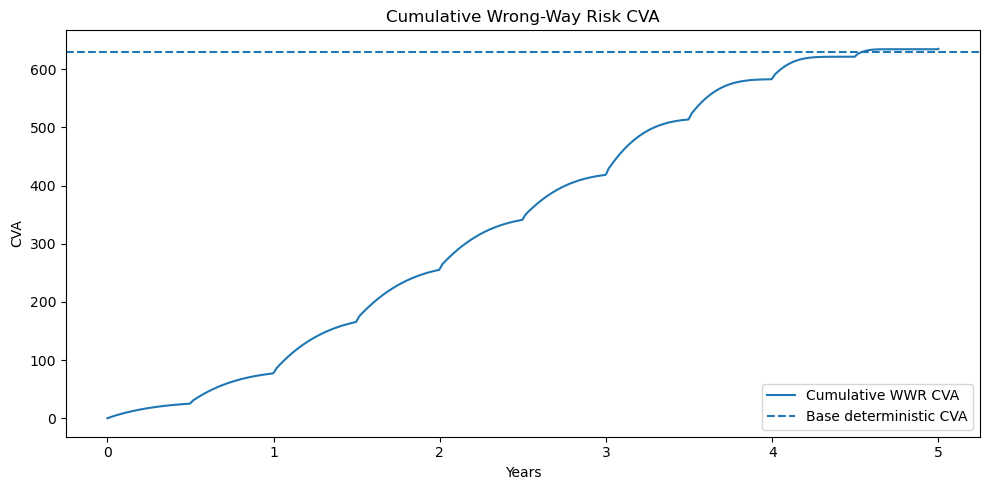

In [67]:
# ------------------------------------------------------------
# Plot cumulative WWR CVA contribution
# ------------------------------------------------------------
# This shows how wrong-way CVA builds up through time.
# ------------------------------------------------------------

wwr_detail = wwr_result.detail.copy()
wwr_detail["cumulative_wwr_cva"] = (
    wwr_detail["wwr_cva_contribution"].cumsum()
)

plt.figure(figsize=(10, 5))
plt.plot(
    wwr_detail["time"],
    wwr_detail["cumulative_wwr_cva"],
    label="Cumulative WWR CVA",
)
plt.axhline(
    xva_result.cva,
    linestyle="--",
    label="Base deterministic CVA",
)
plt.title("Cumulative Wrong-Way Risk CVA")
plt.xlabel("Years")
plt.ylabel("CVA")
plt.legend()
plt.tight_layout()
plt.show()

## Wrong-way risk interpretation

The base CVA engine assumes that exposure and counterparty default risk are
independent. Wrong-way risk relaxes this assumption by making counterparty hazard
rates path-dependent and correlated with the interest-rate shocks used in the
exposure simulation.

The deterministic CVA calculation uses:

\[
EE_c(t_i) \times PD_C(t_{i-1},t_i)
\]

The wrong-way-risk calculation instead uses:

\[
\mathbb{E}
\left[
E_{c,m}(t_i)
PD_{C,m}(t_{i-1},t_i)
\right]
\]

This distinction matters because exposure and default probability may be high in
the same scenarios. If this expected product is larger than the product of the
averages, CVA increases.

The sign and magnitude of the wrong-way effect depend on the relationship between
swap exposure and the risk factor driving counterparty credit intensity.

# Model validation and sanity checks

This section collects the main consistency checks used throughout the notebook.
The goal is to verify that the pricing, collateral, credit, XVA, stress, and
wrong-way risk components behave as expected.

In [68]:
# ------------------------------------------------------------
# Model validation summary
# ------------------------------------------------------------
# These checks collect the main numerical sanity tests used
# throughout the notebook.
#
# This is useful because a CVA engine has many moving parts:
#   - swap pricing
#   - exposure simulation
#   - collateral logic
#   - credit curves
#   - first-to-default CVA/DVA
#   - stress scenarios
#   - wrong-way risk
#
# The table below gives a compact pass/fail view of the main checks.
# ------------------------------------------------------------

validation_checks = {
    "Par swap initial value close to zero": np.isclose(
        swap_values[:, 0].mean(),
        0.0,
        atol=1e-6,
    ),
    "Initial swap value identical across paths": np.isclose(
        swap_values[:, 0].std(),
        0.0,
        atol=1e-10,
    ),
    "Perfect collateral eliminates positive exposure": np.isclose(
        perfect_pos_exp.max(),
        0.0,
        atol=1e-10,
    ),
    "Perfect collateral eliminates negative exposure": np.isclose(
        perfect_neg_exp.max(),
        0.0,
        atol=1e-10,
    ),
    "Counterparty survival starts at one": np.isclose(
        counterparty_curve.survival_probability(0.0),
        1.0,
    ),
    "Counterparty survival decreases by maturity": (
        counterparty_curve.survival_probability(5.0)
        < counterparty_curve.survival_probability(0.0)
    ),
    "FTD CVA below unilateral CVA": xva_result.cva <= unilateral_cva,
    "FTD DVA below unilateral DVA": xva_result.dva <= unilateral_dva,
    "Counterparty stress increases CVA": (
        cp_stress["CVA"] > base["CVA"]
    ),
    "Self stress increases DVA": (
        self_stress["DVA"] > base["DVA"]
    ),
    "Collateral stress increases collateralized EE": (
        coll_stress["average_collateralized_EE"]
        > base["average_collateralized_EE"]
    ),
    "Collateral stress increases collateralized ENE": (
        coll_stress["average_collateralized_ENE"]
        > base["average_collateralized_ENE"]
    ),
    "Positive WWR correlation increases CVA vs zero correlation": (
        wwr_correlation_summary.loc[
            wwr_correlation_summary["correlation"] == 0.50,
            "incremental_vs_zero_corr",
        ].iloc[0] > 0
    ),
}

validation_summary = pd.DataFrame(
    validation_checks.items(),
    columns=["check", "passed"],
)

validation_summary

,check,passed
0,Par swap initial value close to zero,True
1,Initial swap value identical across paths,True
2,Perfect collateral eliminates positive exposure,True
3,Perfect collateral eliminates negative exposure,True
4,Counterparty survival starts at one,True
5,Counterparty survival decreases by maturity,True
6,FTD CVA below unilateral CVA,True
7,FTD DVA below unilateral DVA,True
8,Counterparty stress increases CVA,True
9,Self stress increases DVA,True


In [69]:
# ------------------------------------------------------------
# Overall validation status
# ------------------------------------------------------------
# This returns True only if every individual validation check passed.
# ------------------------------------------------------------

all_checks_passed = validation_summary["passed"].all()

print(f"All validation checks passed: {all_checks_passed}")

All validation checks passed: True


# Final results

This section collects the main base-case outputs and wrong-way risk extension
results in one compact table. These values are useful for the README, report,
and project summary.

In [70]:
# ------------------------------------------------------------
# Final model results
# ------------------------------------------------------------
# This table collects the main outputs of the base case and
# wrong-way risk extension.
#
# It is intended to provide one compact summary of the project:
#   - risk-free swap value
#   - exposure metrics
#   - collateralized exposure metrics
#   - CVA/DVA outputs
#   - wrong-way risk outputs
# ------------------------------------------------------------

final_results = pd.DataFrame([
    {
        "category": "Swap",
        "metric": "Risk-free initial value",
        "value": risk_free_value,
    },
    {
        "category": "Exposure",
        "metric": "Average uncollateralized EE",
        "value": ee.mean(),
    },
    {
        "category": "Exposure",
        "metric": "Average uncollateralized ENE",
        "value": ene.mean(),
    },
    {
        "category": "Exposure",
        "metric": "Peak uncollateralized PFE 99%",
        "value": pfe_99.max(),
    },
    {
        "category": "Collateral",
        "metric": "Average collateralized EE",
        "value": coll_ee.mean(),
    },
    {
        "category": "Collateral",
        "metric": "Average collateralized ENE",
        "value": coll_ene.mean(),
    },
    {
        "category": "Collateral",
        "metric": "Peak collateralized PFE 99%",
        "value": coll_pfe_99.max(),
    },
    {
        "category": "XVA",
        "metric": "Base first-to-default CVA",
        "value": xva_result.cva,
    },
    {
        "category": "XVA",
        "metric": "Base first-to-default DVA",
        "value": xva_result.dva,
    },
    {
        "category": "XVA",
        "metric": "Base net XVA adjustment",
        "value": -xva_result.cva + xva_result.dva,
    },
    {
        "category": "XVA",
        "metric": "Base adjusted value",
        "value": xva_result.adjusted_value,
    },
    {
        "category": "Stress",
        "metric": "Counterparty stress CVA",
        "value": xva_stress_summary.loc[
            xva_stress_summary["scenario"] == "Counterparty credit stress",
            "CVA",
        ].iloc[0],
    },
    {
        "category": "Stress",
        "metric": "Self stress DVA",
        "value": xva_stress_summary.loc[
            xva_stress_summary["scenario"] == "Self credit stress",
            "DVA",
        ].iloc[0],
    },
    {
        "category": "Stress",
        "metric": "Joint credit + collateral stress adjusted value",
        "value": xva_stress_summary.loc[
            xva_stress_summary["scenario"] == "Joint credit + collateral stress",
            "adjusted_value",
        ].iloc[0],
    },
    {
        "category": "WWR",
        "metric": "WWR CVA at rho = 0.50",
        "value": wwr_correlation_summary.loc[
            wwr_correlation_summary["correlation"] == 0.50,
            "WWR_CVA",
        ].iloc[0],
    },
    {
        "category": "WWR",
        "metric": "Pure WWR impact at rho = 0.50",
        "value": wwr_correlation_summary.loc[
            wwr_correlation_summary["correlation"] == 0.50,
            "incremental_vs_zero_corr",
        ].iloc[0],
    },
])

final_results

,category,metric,value
0,Swap,Risk-free initial value,0.000000
1,Exposure,Average uncollateralized EE,19500.050482
2,Exposure,Average uncollateralized ENE,56792.348111
3,Exposure,Peak uncollateralized PFE 99%,267424.118188
4,Collateral,Average collateralized EE,16603.194192
5,Collateral,Average collateralized ENE,45832.652218
6,Collateral,Peak collateralized PFE 99%,231106.029843
7,XVA,Base first-to-default CVA,630.333128
8,XVA,Base first-to-default DVA,1492.871910
9,XVA,Base net XVA adjustment,862.538782


## EVT tail exposure extension

Empirical Monte Carlo PFE estimates become noisy at very high quantiles because
only a small number of paths determine the estimate. For example, with 10,000
paths, the 99.9% empirical quantile is driven by roughly the top 10 observations.

To obtain smoother tail estimates, the project applies Peaks-over-Threshold EVT
to collateralized positive exposure. At each time point, the threshold is set to
the 95th percentile of collateralized positive exposure. Exceedances above this
threshold are modeled using a Generalized Pareto Distribution.

The EVT-based PFE estimate is then compared with the empirical Monte Carlo PFE
at 99.5% and 99.9%. This provides an additional tail-risk view of future
counterparty exposure.

In [71]:
# ------------------------------------------------------------
# Import EVT tail exposure tools
# ------------------------------------------------------------
# EVT is used to estimate extreme PFE levels by fitting a
# Generalized Pareto Distribution to high exposure exceedances.
# ------------------------------------------------------------

from src.evt.tail_exposure import (
    evt_pfe_profile,
    evt_summary_at_peak,
    filter_evt_profile
)

In [72]:
# ------------------------------------------------------------
# EVT-smoothed PFE at 99.5%
# ------------------------------------------------------------
# We fit a GPD to exceedances above the 95th percentile of
# collateralized positive exposure at each time point.
#
# The target quantile is 99.5%, which is more tail-focused than
# the standard empirical 95% and 99% PFE profiles.
# ------------------------------------------------------------

evt_pfe_995 = evt_pfe_profile(
    exposure_paths=coll_pos_exp,
    time_grid=hw_sim.time_grid,
    target_quantile=0.995,
    threshold_quantile=0.95,
    min_exceedances=100,
    start_index=1,
)

evt_pfe_995.head()

,time,threshold,threshold_quantile,n_observations,n_exceedances,exceedance_probability,shape,scale,empirical_quantile,evt_quantile
0,0.003968,34125.876298,0.95,10000,500,0.05,-0.112019,3848.516631,42015.093906,41936.808192
1,0.007937,38778.189933,0.95,10000,500,0.05,-0.133107,5467.463228,49572.266014,49621.111827
2,0.011905,41816.955944,0.95,10000,500,0.05,-0.062638,6248.878427,55067.330735,55216.046973
3,0.015873,44169.871713,0.95,10000,500,0.05,-0.048271,6927.648336,58393.432242,59266.829062
4,0.019841,46150.016866,0.95,10000,500,0.05,-0.070985,7766.659510,62660.557062,62648.385958


In [73]:
# ------------------------------------------------------------
# EVT-smoothed PFE at 99.9%
# ------------------------------------------------------------
# The 99.9% empirical quantile is very noisy with 10,000 paths
# because it relies on roughly the top 10 observations.
#
# EVT uses the broader tail above the 95% threshold instead.
# ------------------------------------------------------------

evt_pfe_999 = evt_pfe_profile(
    exposure_paths=coll_pos_exp,
    time_grid=hw_sim.time_grid,
    target_quantile=0.999,
    threshold_quantile=0.95,
    min_exceedances=100,
    start_index=1,
)

evt_pfe_999.head()

,time,threshold,threshold_quantile,n_observations,n_exceedances,exceedance_probability,shape,scale,empirical_quantile,evt_quantile
0,0.003968,34125.876298,0.95,10000,500,0.05,-0.112019,3848.516631,45237.387995,46315.938213
1,0.007937,38778.189933,0.95,10000,500,0.05,-0.133107,5467.463228,55024.923049,55451.046512
2,0.011905,41816.955944,0.95,10000,500,0.05,-0.062638,6248.878427,61294.298539,63497.980423
3,0.015873,44169.871713,0.95,10000,500,0.05,-0.048271,6927.648336,68038.022900,68865.872287
4,0.019841,46150.016866,0.95,10000,500,0.05,-0.070985,7766.659510,71130.868267,72679.567863


In [74]:
# ------------------------------------------------------------
# EVT peak PFE summaries
# ------------------------------------------------------------
# These tables identify the time point where EVT-estimated PFE
# is largest and report the fitted GPD parameters at that point.
# ------------------------------------------------------------

evt_995_peak_summary = evt_summary_at_peak(evt_pfe_995)
evt_999_peak_summary = evt_summary_at_peak(evt_pfe_999)

evt_995_peak_summary

,metric,value
0,Peak EVT PFE time,1.007937
1,Peak empirical PFE,236638.606229
2,Peak EVT PFE,241445.973861
3,Threshold at peak,183979.634356
4,GPD shape at peak,-0.464063
5,GPD scale at peak,40622.001606
6,Exceedances at peak,500.000000


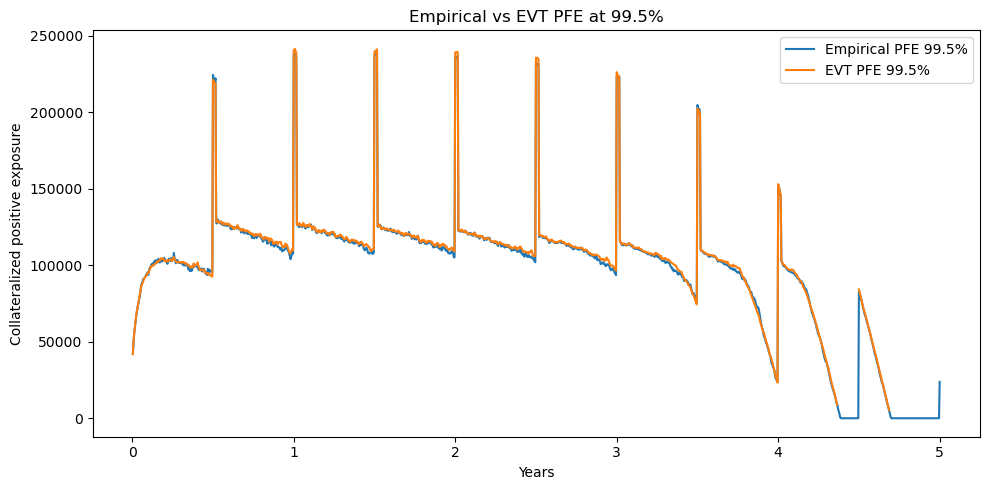

In [75]:
# ------------------------------------------------------------
# Plot empirical vs EVT PFE at 99.5%
# ------------------------------------------------------------
# Empirical PFE is directly estimated from Monte Carlo quantiles.
# EVT PFE smooths the high tail using a GPD fit above the threshold.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(
    evt_pfe_995["time"],
    evt_pfe_995["empirical_quantile"],
    label="Empirical PFE 99.5%",
)
plt.plot(
    evt_pfe_995["time"],
    evt_pfe_995["evt_quantile"],
    label="EVT PFE 99.5%",
)
plt.title("Empirical vs EVT PFE at 99.5%")
plt.xlabel("Years")
plt.ylabel("Collateralized positive exposure")
plt.legend()
plt.tight_layout()
plt.show()

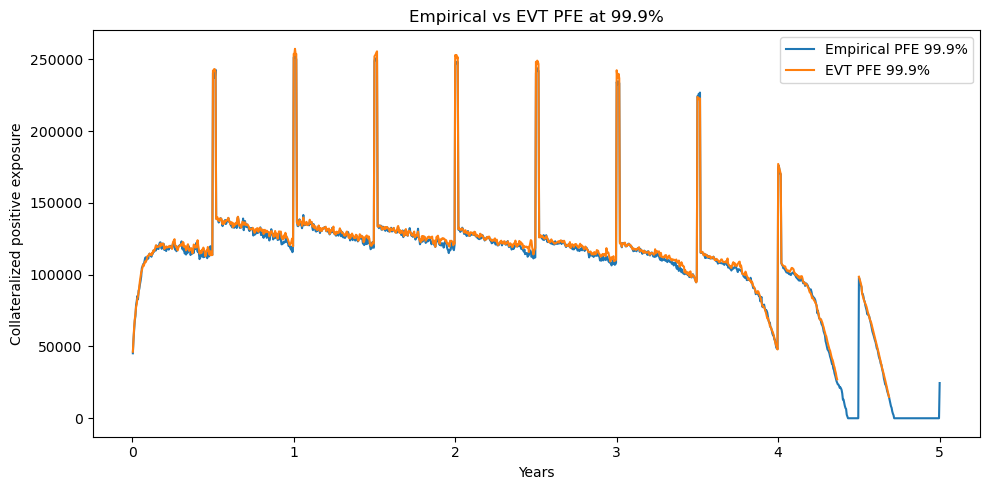

In [76]:
# ------------------------------------------------------------
# Plot empirical vs EVT PFE at 99.9%
# ------------------------------------------------------------
# At 99.9%, EVT is especially useful because the empirical
# quantile is based on very few extreme observations.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(
    evt_pfe_999["time"],
    evt_pfe_999["empirical_quantile"],
    label="Empirical PFE 99.9%",
)
plt.plot(
    evt_pfe_999["time"],
    evt_pfe_999["evt_quantile"],
    label="EVT PFE 99.9%",
)
plt.title("Empirical vs EVT PFE at 99.9%")
plt.xlabel("Years")
plt.ylabel("Collateralized positive exposure")
plt.legend()
plt.tight_layout()
plt.show()

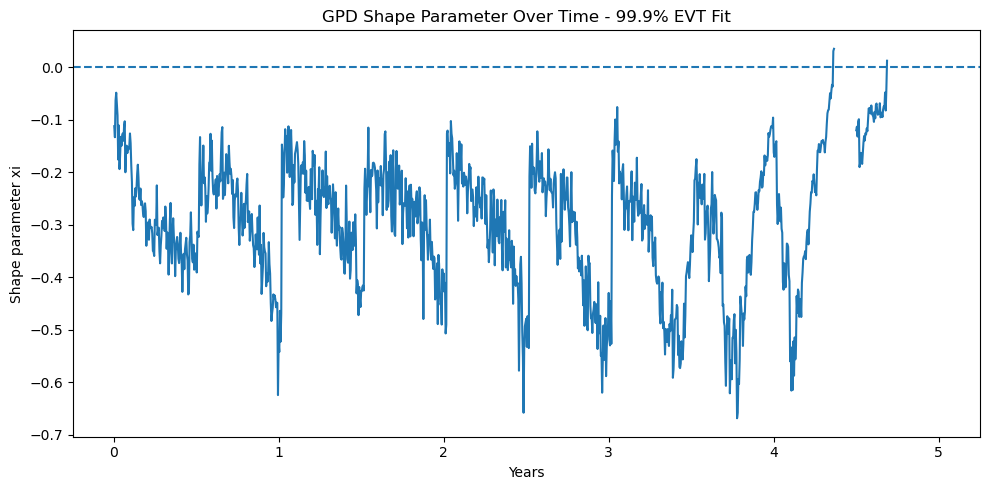

In [77]:
# ------------------------------------------------------------
# Plot GPD shape parameter over time
# ------------------------------------------------------------
# The GPD shape parameter xi controls tail heaviness:
#
#   xi > 0  : heavy tail
#   xi = 0  : exponential-type tail
#   xi < 0  : bounded tail
#
# Exposure tails may vary across the life of the swap.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(evt_pfe_999["time"], evt_pfe_999["shape"])
plt.axhline(0.0, linestyle="--")
plt.title("GPD Shape Parameter Over Time - 99.9% EVT Fit")
plt.xlabel("Years")
plt.ylabel("Shape parameter xi")
plt.tight_layout()
plt.show()

In [78]:
# ------------------------------------------------------------
# Compact EVT PFE comparison table
# ------------------------------------------------------------
# This table is useful for the README because it summarizes the
# peak tail exposure under empirical Monte Carlo and EVT.
# ------------------------------------------------------------

evt_comparison = pd.DataFrame([
    {
        "target_quantile": "99.5%",
        "peak_empirical_pfe": evt_pfe_995["empirical_quantile"].max(),
        "peak_evt_pfe": evt_pfe_995["evt_quantile"].max(),
        "evt_minus_empirical": (
            evt_pfe_995["evt_quantile"].max()
            - evt_pfe_995["empirical_quantile"].max()
        ),
    },
    {
        "target_quantile": "99.9%",
        "peak_empirical_pfe": evt_pfe_999["empirical_quantile"].max(),
        "peak_evt_pfe": evt_pfe_999["evt_quantile"].max(),
        "evt_minus_empirical": (
            evt_pfe_999["evt_quantile"].max()
            - evt_pfe_999["empirical_quantile"].max()
        ),
    },
])

evt_comparison

,target_quantile,peak_empirical_pfe,peak_evt_pfe,evt_minus_empirical
0,99.5%,239159.525622,241445.973861,2286.448239
1,99.9%,252244.879080,257267.071471,5022.192392


In [79]:
# ------------------------------------------------------------
# Filter EVT profiles to meaningful exposure dates
# ------------------------------------------------------------
# Near maturity, exposure often collapses toward zero. EVT fits
# in those regions are less informative, so we filter out dates
# where the 95% threshold is very small.
# ------------------------------------------------------------

evt_pfe_995_filtered = filter_evt_profile(
    evt_profile=evt_pfe_995,
    min_threshold=1_000,
)

evt_pfe_999_filtered = filter_evt_profile(
    evt_profile=evt_pfe_999,
    min_threshold=1_000,
)

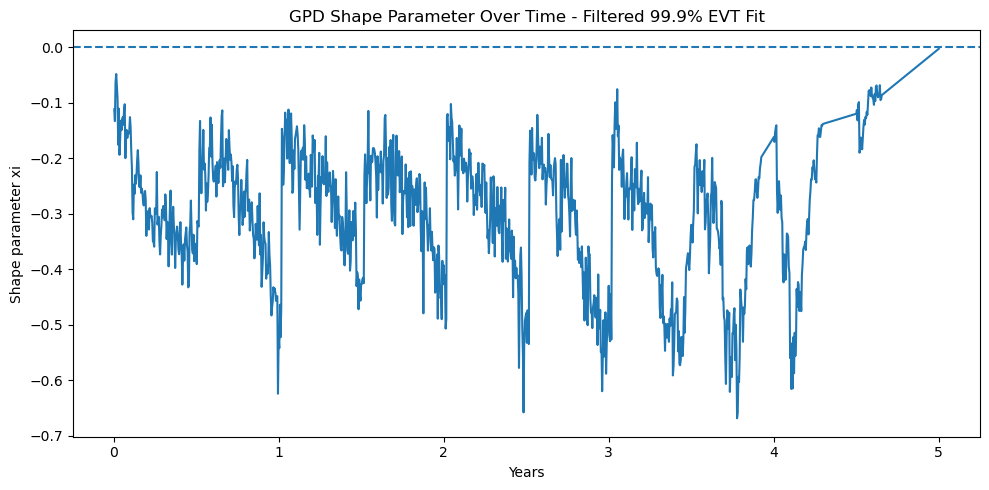

In [80]:
plt.figure(figsize=(10, 5))
plt.plot(
    evt_pfe_999_filtered["time"],
    evt_pfe_999_filtered["shape"],
)
plt.axhline(0.0, linestyle="--")
plt.title("GPD Shape Parameter Over Time - Filtered 99.9% EVT Fit")
plt.xlabel("Years")
plt.ylabel("Shape parameter xi")
plt.tight_layout()
plt.show()

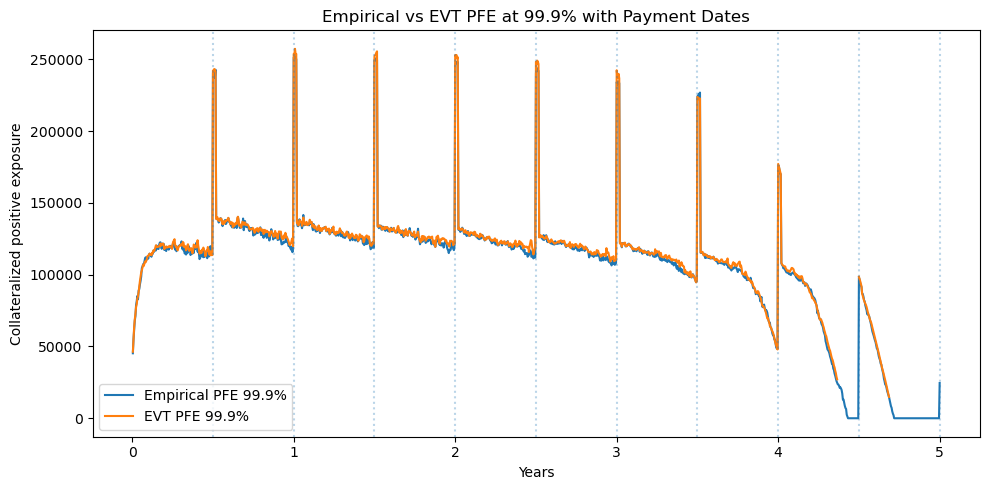

In [81]:
# ------------------------------------------------------------
# Plot EVT PFE with payment dates
# ------------------------------------------------------------
# Vertical lines mark swap payment dates. Spikes in exposure/PFE
# often occur around payment dates because the remaining cashflow
# structure changes discretely.
# ------------------------------------------------------------

payment_times = swap.payment_times

plt.figure(figsize=(10, 5))
plt.plot(
    evt_pfe_999["time"],
    evt_pfe_999["empirical_quantile"],
    label="Empirical PFE 99.9%",
)
plt.plot(
    evt_pfe_999["time"],
    evt_pfe_999["evt_quantile"],
    label="EVT PFE 99.9%",
)

for payment_time in payment_times:
    plt.axvline(payment_time, linestyle=":", alpha=0.3)

plt.title("Empirical vs EVT PFE at 99.9% with Payment Dates")
plt.xlabel("Years")
plt.ylabel("Collateralized positive exposure")
plt.legend()
plt.tight_layout()
plt.show()

The vertical dotted lines mark the semiannual swap payment dates. The spikes in
both empirical and EVT PFE align closely with these dates, confirming that the
sharp movements are driven by the discrete swap cashflow structure rather than
by numerical instability in the EVT fit.

Because the swap is repriced from the remaining cashflows at each simulation
date, payment dates create discontinuities in the exposure profile. EVT is fitted
cross-sectionally at each time point, so it preserves these discontinuities
instead of smoothing them away.

In [82]:
# ------------------------------------------------------------
# EVT threshold sensitivity
# ------------------------------------------------------------
# EVT estimates can depend on the selected threshold. We compare
# several threshold quantiles to check whether peak EVT PFE is stable.
# ------------------------------------------------------------

evt_thresholds = [0.90, 0.95, 0.975]
evt_targets = [0.995, 0.999]

evt_threshold_rows = []

for target_q in evt_targets:
    for threshold_q in evt_thresholds:
        profile = evt_pfe_profile(
            exposure_paths=coll_pos_exp,
            time_grid=hw_sim.time_grid,
            target_quantile=target_q,
            threshold_quantile=threshold_q,
            min_exceedances=50,
            start_index=1,
        )

        valid_profile = profile.dropna(subset=["evt_quantile"])

        evt_threshold_rows.append({
            "target_quantile": target_q,
            "threshold_quantile": threshold_q,
            "peak_empirical_pfe": valid_profile["empirical_quantile"].max(),
            "peak_evt_pfe": valid_profile["evt_quantile"].max(),
            "median_gpd_shape": valid_profile["shape"].median(),
            "min_exceedances": valid_profile["n_exceedances"].min(),
            "median_exceedances": valid_profile["n_exceedances"].median(),
        })

evt_threshold_sensitivity = pd.DataFrame(evt_threshold_rows)
evt_threshold_sensitivity

,target_quantile,threshold_quantile,peak_empirical_pfe,peak_evt_pfe,median_gpd_shape,min_exceedances,median_exceedances
0,0.995,0.900,239159.525622,242888.221663,-0.326105,53,1000.0
1,0.995,0.950,239159.525622,241445.973861,-0.276859,53,500.0
2,0.995,0.975,239159.525622,239391.150120,-0.236398,53,250.0
3,0.999,0.900,252244.879080,257135.555770,-0.326105,53,1000.0
4,0.999,0.950,252244.879080,257267.071471,-0.276859,53,500.0
5,0.999,0.975,252244.879080,253799.909525,-0.236398,53,250.0


### EVT tail exposure interpretation

The EVT-smoothed PFE estimates are slightly above the empirical Monte Carlo PFE
estimates at both 99.5% and 99.9%. This suggests that the GPD tail fit produces
a modestly more conservative estimate of extreme collateralized positive
exposure.

The fitted GPD shape parameter is mostly negative, indicating bounded-tail
behavior. This is plausible because the underlying exposure is generated by a
finite-maturity interest rate swap under a Gaussian one-factor Hull-White model
with collateralization.

The sharp movements in the PFE profile occur around swap payment dates, where
the remaining cashflow structure changes discretely. EVT is applied
cross-sectionally at each time point, so it reflects these exposure jumps rather
than smoothing them away.

Near maturity, exposure collapses for many paths, making EVT fits less
informative. For interpretation, filtered EVT profiles can be used to exclude
dates where the tail threshold is close to zero.

In [83]:
# ------------------------------------------------------------
# Stylized initial margin proxy
# ------------------------------------------------------------
# Initial margin is estimated as a 99% quantile of adverse MTM
# changes over a 10-step margin period of risk.
# ------------------------------------------------------------

from src.collateral.margining import (
    compute_initial_margin_profile,
    collateralized_positive_exposure_with_initial_margin,
)

im_profile = compute_initial_margin_profile(
    values=swap_values,
    margin_period_steps=10,
    quantile=0.99,
)

coll_pos_exp_with_im = collateralized_positive_exposure_with_initial_margin(
    values=swap_values,
    collateral=collateral,
    initial_margin=im_profile,
)

coll_ee_with_im = expected_exposure(coll_pos_exp_with_im)
coll_pfe_99_with_im = potential_future_exposure(
    coll_pos_exp_with_im,
    quantile=0.99,
)

im_impact_summary = pd.DataFrame([
    {
        "metric": "Average collateralized EE without IM",
        "value": coll_ee.mean(),
    },
    {
        "metric": "Average collateralized EE with IM",
        "value": coll_ee_with_im.mean(),
    },
    {
        "metric": "Peak collateralized PFE 99 without IM",
        "value": coll_pfe_99.max(),
    },
    {
        "metric": "Peak collateralized PFE 99 with IM",
        "value": coll_pfe_99_with_im.max(),
    },
    {
        "metric": "Peak initial margin",
        "value": im_profile.max(),
    },
    {
        "metric": "Average initial margin",
        "value": im_profile.mean(),
    },
])

im_impact_summary

,metric,value
0,Average collateralized EE without IM,16603.194192
1,Average collateralized EE with IM,8502.752612
2,Peak collateralized PFE 99 without IM,231106.029843
3,Peak collateralized PFE 99 with IM,196671.547163
4,Peak initial margin,174922.310587
5,Average initial margin,36406.392170


In [84]:
# ------------------------------------------------------------
# Recovery rate sensitivity
# ------------------------------------------------------------
# CVA/DVA depend directly on LGD = 1 - recovery. We test how
# valuation adjustments change under different recovery assumptions.
# ------------------------------------------------------------

recovery_rates = [0.20, 0.40, 0.60]

recovery_rows = []

for recovery in recovery_rates:
    cp_curve_rec = build_hazard_curve_from_spread_table(
        spread_table=credit_spreads,
        spread_column="counterparty_base",
        recovery_rate=recovery,
    )

    self_curve_rec = build_hazard_curve_from_spread_table(
        spread_table=credit_spreads,
        spread_column="self_base",
        recovery_rate=recovery,
    )

    result_rec = compute_bilateral_first_to_default_cva_dva(
        time_grid=hw_sim.time_grid,
        expected_positive_exposure=coll_ee,
        expected_negative_exposure=coll_ene,
        counterparty_curve=cp_curve_rec,
        self_curve=self_curve_rec,
        discount_curve=curve,
        risk_free_value=risk_free_value,
    )

    recovery_rows.append({
        "recovery_rate": recovery,
        "LGD": 1.0 - recovery,
        "CVA": result_rec.cva,
        "DVA": result_rec.dva,
        "adjusted_value": result_rec.adjusted_value,
    })

recovery_sensitivity = pd.DataFrame(recovery_rows)
recovery_sensitivity

,recovery_rate,LGD,CVA,DVA,adjusted_value
0,0.2,0.8,638.151694,1519.727872,881.576178
1,0.4,0.6,630.333128,1492.871910,862.538782
2,0.6,0.4,615.084653,1441.028482,825.943829


# Save output tables

This section saves the main result tables to CSV files under the `outputs/`
folder so they can be reused in the README, report, or future analysis scripts.

In [85]:
# ------------------------------------------------------------
# Save key output tables
# ------------------------------------------------------------
# These CSV files make the notebook outputs reusable in the README,
# report, or later plotting scripts.
#
# Output location:
#   PROJECT_ROOT / "outputs"
# ------------------------------------------------------------

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

exposure_summary.to_csv(
    OUTPUT_DIR / "exposure_summary.csv",
    index=False,
)

collateral_exposure_summary.to_csv(
    OUTPUT_DIR / "collateral_exposure_summary.csv",
    index=False,
)

collateral_scenario_summary.to_csv(
    OUTPUT_DIR / "collateral_scenario_summary.csv",
    index=False,
)

credit_key_summary.to_csv(
    OUTPUT_DIR / "credit_key_summary.csv",
    index=False,
)

xva_summary.to_csv(
    OUTPUT_DIR / "xva_summary.csv",
    index=False,
)

xva_comparison.to_csv(
    OUTPUT_DIR / "xva_comparison.csv",
    index=False,
)

xva_stress_compact.to_csv(
    OUTPUT_DIR / "xva_stress_summary.csv",
    index=False,
)

xva_stress_impacts_compact.to_csv(
    OUTPUT_DIR / "xva_stress_impacts.csv",
    index=False,
)

wwr_correlation_summary.to_csv(
    OUTPUT_DIR / "wrong_way_risk_summary.csv",
    index=False,
)

validation_summary.to_csv(
    OUTPUT_DIR / "validation_summary.csv",
    index=False,
)

final_results.to_csv(
    OUTPUT_DIR / "final_results.csv",
    index=False,
)

evt_pfe_995.to_csv(
    OUTPUT_DIR / "evt_pfe_995_profile.csv",
    index=False,
)

evt_pfe_999.to_csv(
    OUTPUT_DIR / "evt_pfe_999_profile.csv",
    index=False,
)

evt_comparison.to_csv(
    OUTPUT_DIR / "evt_pfe_comparison.csv",
    index=False,
)

print(f"Saved output tables to: {OUTPUT_DIR}")

Saved output tables to: /Users/lorenzoalessandra/Desktop/UNI/Projects/monte-carlo-cva-interest-rate-swap/outputs


In [86]:
# ------------------------------------------------------------
# List saved output files
# ------------------------------------------------------------
# Quick check that all CSV files were written successfully.
# ------------------------------------------------------------

saved_files = sorted([path.name for path in OUTPUT_DIR.glob("*.csv")])

pd.DataFrame(saved_files, columns=["saved_file"])

,saved_file
0,collateral_exposure_summary.csv
1,collateral_scenario_summary.csv
2,credit_key_summary.csv
3,evt_pfe_995_profile.csv
4,evt_pfe_999_profile.csv
5,evt_pfe_comparison.csv
6,exposure_summary.csv
7,final_results.csv
8,validation_summary.csv
9,wrong_way_risk_summary.csv


## Model limitations

This notebook is a transparent research implementation rather than a production
XVA system. The main simplifications are stylized credit spreads rather than
bootstrapped CDS curves, one-factor Hull-White dynamics with historical
calibration, single-curve swap pricing, simplified collateral mechanics,
deterministic base hazard curves, stylized wrong-way risk, and EVT fits applied
independently at each time point.

These limitations are documented explicitly so that the model outputs are
interpreted as a controlled quantitative experiment rather than production
valuation numbers.